In [1]:
# ================================================================
# 📊 ANÁLISIS EXPLORATORIO – ENCUESTA MUNDIAL DE SALUD ESCOLAR (EMSE 2018) – ARGENTINA
# Taller de Programación | Maestría en Economía Aplicada – UBA
# Primera Exposición Grupal | 5 de noviembre de 2025
# ---------------------------------------------------------------
# Autores:
#   • Julián Delgadillo Marín
#   • Alejandro Jiménez Alcocer
#   • Christian Campos
#
# Objetivo:
# Realizar la limpieza, exploración y análisis descriptivo inicial de la base de microdatos EMSE 2018
# para comprender su estructura, evaluar la calidad de la información, identificar variables relevantes
# y generar visualizaciones para la presentación grupal del curso.
# ================================================================

"""
Análisis exploratorio de la Encuesta Mundial de Salud Escolar (EMSE 2018) – Argentina
Taller de Programación | Maestría en Finanzas – UBA | Primera exposición grupal

Este script realiza la limpieza, exploración y análisis descriptivo inicial de la base de microdatos
de la EMSE 2018, publicada por el Ministerio de Salud de la Nación.
El objetivo es comprender la estructura de la base, identificar variables relevantes
(asociadas a hábitos de salud, consumo de tabaco y alcohol, actividad física, alimentación, etc.)
y generar visualizaciones básicas para la presentación grupal del curso.

Estructura general:
1. Carga y detección de codificación del archivo CSV.
2. Corrección de caracteres mal decodificados.
3. Análisis de valores faltantes y filtrado de variables completas.
4. Integración con el libro de códigos para generar un diccionario de variables.
5. Construcción de un subconjunto temático (salud y hábitos).
6. Análisis descriptivo y visualizaciones.

Autores: Julián Delgadillo Marín, Alejandro Alcocer, Christian Campos
Fecha: 5 de Noviembre 2025
"""

# Subir el archivo al entorno de Colab (Base de datos)
from google.colab import files
uploaded = files.upload()

Saving EMSE_DatosAbiertos.csv to EMSE_DatosAbiertos.csv


In [2]:
# Cargar la base de datos
import pandas as pd

# Cargar el CSV (ajusta el nombre si es distinto)
df = pd.read_csv("EMSE_DatosAbiertos.csv", encoding='latin1')  # a veces 'utf-8' o 'latin1' según acentos

In [3]:
# Exploración inicial

# Ver las primeras filas
df.head()

# Dimensiones del dataset
print("Filas:", df.shape[0], "Columnas:", df.shape[1])

# Información general
df.info()

# Estadísticos básicos
df.describe(include='all').transpose().head(10)

Filas: 56981 Columnas: 309
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56981 entries, 0 to 56980
Columns: 309 entries, sitio to psu
dtypes: float64(154), int64(3), object(152)
memory usage: 134.3+ MB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
sitio,56981,1,AG,56981,NaN,NaN,NaN,NaN,NaN,NaN,NaN
record,56981.0,NaN,NaN,NaN,28535.389832,16479.971553,1.0,14263.0,28522.0,42804.0,57095.0
q1,56873.0,NaN,NaN,NaN,4.905403,1.358115,1.0,4.0,5.0,6.0,8.0
texto_q1,56873,8,14 aÃ±os,12946,NaN,NaN,NaN,NaN,NaN,NaN,NaN
q2,56445.0,NaN,NaN,NaN,1.520188,0.499597,1.0,1.0,2.0,2.0,2.0
texto_q2,56981,3,Femenino,29362,NaN,NaN,NaN,NaN,NaN,NaN,NaN
q3,55920.0,NaN,NaN,NaN,3.064485,1.324451,1.0,2.0,3.0,4.0,5.0
texto_q3,56981,6,2do aÃ±o/11vo grado nivel Polimodal o 4to aÃ±o...,13275,NaN,NaN,NaN,NaN,NaN,NaN,NaN
q4,36052.0,NaN,NaN,NaN,1.642857,0.096898,1.2,1.57,1.64,1.7,2.03
q5,36052.0,NaN,NaN,NaN,60.212193,14.723909,27.0,51.0,58.0,66.0,187.0


In [4]:
# Ver las primeras columnas
df.columns[:30]

Index(['sitio', 'record', 'q1', 'texto_q1', 'q2', 'texto_q2', 'q3', 'texto_q3',
       'q4', 'q5', 'q6', 'texto_q6', 'q10', 'texto_q10', 'q15', 'texto_q15',
       'q16', 'texto_q16', 'q17', 'texto_q17', 'q18', 'texto_q18', 'q19',
       'texto_q19', 'q22', 'texto_q22', 'q23', 'texto_q23', 'q24',
       'texto_q24'],
      dtype='object')

In [5]:
# Examinar una muestra de respuestas textuales:
df[['texto_q1','texto_q2','texto_q3']].head(10)

,texto_q1,texto_q2,texto_q3
0,13 aÃ±os,Femenino,9no grado nivel Primario/Polimodal o 2do aÃ±o ...
1,13 aÃ±os,Femenino,9no grado nivel Primario/Polimodal o 2do aÃ±o ...
2,14 aÃ±os,Masculino,2do aÃ±o/11vo grado nivel Polimodal o 4to aÃ±o...
3,16 aÃ±os,Masculino,9no grado nivel Primario/Polimodal o 2do aÃ±o ...
4,13 aÃ±os,Femenino,9no grado nivel Primario/Polimodal o 2do aÃ±o ...
5,13 aÃ±os,Masculino,9no grado nivel Primario/Polimodal o 2do aÃ±o ...
6,14 aÃ±os,Femenino,2do aÃ±o/11vo grado nivel Polimodal o 4to aÃ±o...
7,12 aÃ±os,Femenino,2do aÃ±o/11vo grado nivel Polimodal o 4to aÃ±o...
8,13 aÃ±os,Masculino,2do aÃ±o/11vo grado nivel Polimodal o 4to aÃ±o...
9,14 aÃ±os,Femenino,9no grado nivel Primario/Polimodal o 2do aÃ±o ...


In [6]:
# Detectar encoding real
!pip install chardet
import chardet

with open("EMSE_DatosAbiertos.csv", 'rb') as f:
    result = chardet.detect(f.read(200000))
result


{'encoding': 'utf-8', 'confidence': 0.99, 'language': ''}

In [7]:
# Bloque para limpiar caracteres mal decodificados: Función para corregir los textos dañados
def fix_encoding(s):
    if isinstance(s, str):
        return s.encode('latin1', errors='ignore').decode('utf-8', errors='ignore')
    return s

# Aplicar la corrección a todas las columnas tipo texto
df = df.applymap(fix_encoding)

# Verificamos las tres primeras variables
df[['texto_q1', 'texto_q2', 'texto_q3']].head(10)


/tmp/ipython-input-2446341064.py:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(fix_encoding)


,texto_q1,texto_q2,texto_q3
0,13 años,Femenino,9no grado nivel Primario/Polimodal o 2do año n...
1,13 años,Femenino,9no grado nivel Primario/Polimodal o 2do año n...
2,14 años,Masculino,2do año/11vo grado nivel Polimodal o 4to año n...
3,16 años,Masculino,9no grado nivel Primario/Polimodal o 2do año n...
4,13 años,Femenino,9no grado nivel Primario/Polimodal o 2do año n...
5,13 años,Masculino,9no grado nivel Primario/Polimodal o 2do año n...
6,14 años,Femenino,2do año/11vo grado nivel Polimodal o 4to año n...
7,12 años,Femenino,2do año/11vo grado nivel Polimodal o 4to año n...
8,13 años,Masculino,2do año/11vo grado nivel Polimodal o 4to año n...
9,14 años,Femenino,9no grado nivel Primario/Polimodal o 2do año n...


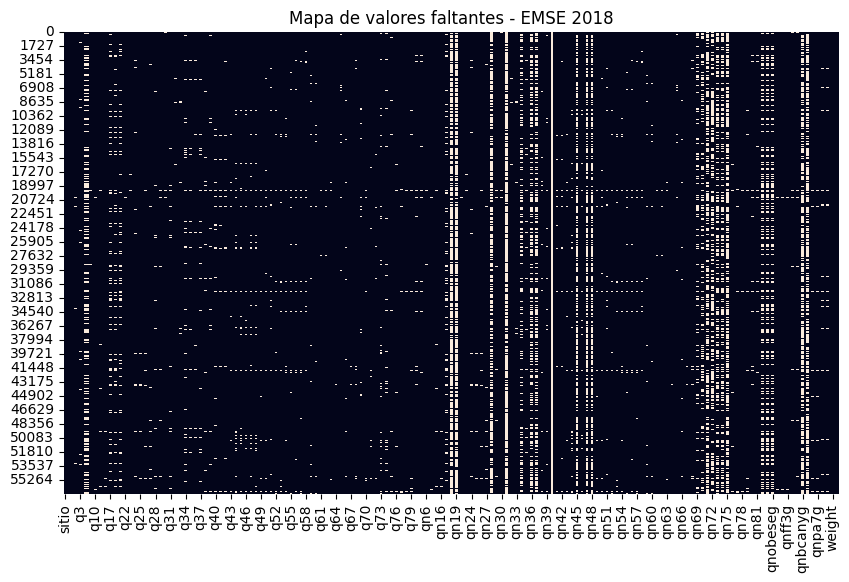

,0
qn40,56981
qn31,45631
qn18,42605
qn19,42231
qnc1g,37285
qnbcanyg,37246
qn48,36300
qn47,36241
qn45,36095
qn75,35407


In [8]:
# Paso 4 – Revisión de valores faltantes
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Mapa de valores faltantes - EMSE 2018")
plt.show()

# Conteo numérico de missing
df.isna().sum().sort_values(ascending=False).head(10)

In [9]:
#Cuantificar los faltantes más relevantes

df.isna().mean().sort_values(ascending=False).head(20)

,0
qn40,1.000000
qn31,0.800811
qn18,0.747705
qn19,0.741142
qnc1g,0.654341
qnbcanyg,0.653656
qn48,0.637054
qn47,0.636019
qn45,0.633457
qn75,0.621383


In [10]:
# Filtrar variables útiles (con pocos faltantes)

# Filtramos las columnas con menos del 20% de NaN
df_reducido = df.loc[:, df.isna().mean() < 0.2]
print("Columnas retenidas:", df_reducido.shape[1])

Columnas retenidas: 285


In [11]:
# # Subir el archivo al entorno de Colab (Libro de códigos)

from google.colab import files
uploaded = files.upload()

Saving libro-de-codigos-emse-2018.xlsx to libro-de-codigos-emse-2018.xlsx


In [12]:
# Cargar el archivo y mirar su estructura
import pandas as pd

codigos = pd.read_excel("libro-de-codigos-emse-2018.xlsx")
codigos.head(30)

,Código variable standard,Código variable ARG (Nº de pregunta),Pregunta,Códigos de respuesta,Etiquetas de respuesta
0,site,NaN,Lugar,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN
2,record,NaN,Nº de registro,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN
4,q1,q1,¿Qué edad tienes?,NaN,NaN
5,NaN,NaN,NaN,1.0,11 años o menos
6,NaN,NaN,NaN,2.0,12 años
7,NaN,NaN,NaN,3.0,13 años
8,NaN,NaN,NaN,4.0,14 años
9,NaN,NaN,NaN,5.0,15 años


In [13]:
# 3️Verificar los nombres de las columnas

codigos.columns

Index(['Código variable standard', 'Código variable ARG (Nº de pregunta)',
       'Pregunta', 'Códigos de respuesta', 'Etiquetas de respuesta'],
      dtype='object')

In [14]:
# Ver los nombres de columnas tal cual están
codigos.columns.tolist()

['Código variable standard',
 'Código variable ARG (Nº de pregunta)',
 'Pregunta',
 'Códigos de respuesta',
 'Etiquetas de respuesta']

In [15]:
# Buscar columnas que contengan la palabra “pregunta”
[c for c in codigos.columns if "preg" in c.lower()]

['Código variable ARG (Nº de pregunta)', 'Pregunta']

In [16]:
# Usar ese nombre automáticamente (sin tener que escribirlo)

# Buscar la columna que contenga la palabra 'pregunta'
col_preg = [c for c in codigos.columns if "preg" in c.lower()][0]
print("Nombre detectado de la columna:", col_preg)

# Extraer los nombres de variables desde esa columna
nombres_vars = codigos[col_preg].dropna().unique().tolist()

print("Total de variables:", len(nombres_vars))
print("Primeros 20 nombres:", nombres_vars[:20])

Nombre detectado de la columna: Código variable ARG (Nº de pregunta)
Total de variables: 72
Primeros 20 nombres: ['q1', 'q2', 'q3', 'q6', 'q7', 'q8', 'q12', 'q18', 'q19', 'q15', 'q16', 'q17', 'q27', 'q28', 'q29', 'q30', 'q31', 'q32', 'q33', 'q34']


In [17]:
# Comparar variables del libro con las columnas del dataset
vars_existentes = [v for v in nombres_vars if v in df.columns]

print("Variables del libro presentes en la base:", len(vars_existentes))
print(vars_existentes)

Variables del libro presentes en la base: 63
['q1', 'q2', 'q3', 'q6', 'q18', 'q19', 'q15', 'q16', 'q17', 'q27', 'q28', 'q29', 'q30', 'q31', 'q32', 'q33', 'q34', 'q35', 'q36', 'q37', 'q38', 'q39', 'q40', 'q41', 'q42', 'q47', 'q48', 'q50', 'q51', 'q52', 'q53', 'q55', 'q56', 'q57', 'q58', 'q59', 'q61', 'q62', 'q63', 'q64', 'q65', 'q66', 'q67', 'q68', 'q69', 'q70', 'q4', 'q5', 'q10', 'q22', 'q23', 'q24', 'q25', 'q26', 'q43', 'q44', 'q45', 'q46', 'q49', 'q54', 'q60', 'q71', 'q72']


In [18]:
# Detección y extracción de preguntas (para Excel)
import pandas as pd

# 1. Cargar el libro de códigos completo
# (read_excel no tiene skip_blank_lines, así que simplemente cargamos todo)
codigos_raw = pd.read_excel("libro-de-codigos-emse-2018.xlsx", header=0)

print("Columnas detectadas en el archivo:")
print(codigos_raw.columns.tolist())

# 2. Detectar automáticamente la columna que contiene las preguntas
col_pregunta = None
for col in codigos_raw.columns:
    ejemplos = codigos_raw[col].dropna().astype(str).head(15)
    if any("?" in e for e in ejemplos):  # detectar signos de pregunta
        col_pregunta = col
        break

if col_pregunta:
    print(f"\nColumna detectada como 'Pregunta': {col_pregunta}")
else:
    print("\nNo se encontró columna con texto de pregunta. Verificar manualmente los encabezados.")

# 3. Detectar la columna de los códigos de variable (q1, q2, etc.)
# Buscar columnas que contengan 'arg', 'preg' o 'variable'
col_codigo = [c for c in codigos_raw.columns if any(x in c.lower() for x in ["arg", "preg", "variable"])][0]
print(f"Columna detectada como 'Código de variable': {col_codigo}")

# 4. Filtrar solo las filas que contienen tanto el código como el texto de pregunta
codigos_filtrado = codigos_raw[[col_codigo, col_pregunta]].dropna()

# 5. Renombrar columnas para mayor claridad
codigos_filtrado.columns = ["Variable", "Descripcion"]

# 6. Limpiar duplicados y espacios en blanco
codigos_filtrado = codigos_filtrado.drop_duplicates().reset_index(drop=True)
codigos_filtrado["Variable"] = codigos_filtrado["Variable"].astype(str).str.strip()
codigos_filtrado["Descripcion"] = codigos_filtrado["Descripcion"].astype(str).str.strip()

# 7. Mostrar un resumen del diccionario generado
print(f"\nDiccionario limpio generado: {codigos_filtrado.shape[0]} variables encontradas\n")
display(codigos_filtrado.head(30))

Columnas detectadas en el archivo:
['Código variable standard', 'Código variable ARG (Nº de pregunta)', 'Pregunta', 'Códigos de respuesta', 'Etiquetas de respuesta']

Columna detectada como 'Pregunta': Pregunta
Columna detectada como 'Código de variable': Código variable standard

Diccionario limpio generado: 158 variables encontradas



,Variable,Descripcion
0,site,Lugar
1,record,Nº de registro
2,q1,¿Qué edad tienes?
3,q2,¿Cuál es tu sexo?
4,q3,¿En qué grado o año estás?
5,q4,"¿Cuál es tu estatura, sin zapatos? (Nota: dato..."
6,q5,"¿Cuánto pesas, sin zapatos? (Nota: dato en ki..."
7,q6,Durante los últimos 30 días ¿con qué frecuenci...
8,q10,"Durante los últimos 7 días, ¿cuántos días comi..."
9,q15,"Durante los últimos 12 meses, Cuantas veces fu..."


In [19]:
# Bloque para unir el libro de códigos con la base de datos

# 1. Tomar las variables que realmente están presentes en el DataFrame principal
vars_existentes = [v for v in codigos_filtrado["Variable"] if v in df.columns]

print(f"Variables presentes en la base: {len(vars_existentes)}")

# 2. Filtrar el diccionario original para conservar solo las variables existentes
diccionario_final = codigos_filtrado[codigos_filtrado["Variable"].isin(vars_existentes)].reset_index(drop=True)

# 3. Mostrar un resumen de las variables activas
print(f"\nDiccionario final de variables activas: {diccionario_final.shape[0]} variables encontradas\n")
display(diccionario_final.head(15))

Variables presentes en la base: 157

Diccionario final de variables activas: 157 variables encontradas



,Variable,Descripcion
0,record,Nº de registro
1,q1,¿Qué edad tienes?
2,q2,¿Cuál es tu sexo?
3,q3,¿En qué grado o año estás?
4,q4,"¿Cuál es tu estatura, sin zapatos? (Nota: dato..."
5,q5,"¿Cuánto pesas, sin zapatos? (Nota: dato en ki..."
6,q6,Durante los últimos 30 días ¿con qué frecuenci...
7,q10,"Durante los últimos 7 días, ¿cuántos días comi..."
8,q15,"Durante los últimos 12 meses, Cuantas veces fu..."
9,q16,"Durante los últimos 12 meses, ¿cuántas veces p..."


In [20]:
# Bloque sugerido de código para explorarlas todas
pd.set_option('display.max_rows', None)
display(diccionario_final[['Variable', 'Descripcion']])

,Variable,Descripcion
0,record,Nº de registro
1,q1,¿Qué edad tienes?
2,q2,¿Cuál es tu sexo?
3,q3,¿En qué grado o año estás?
4,q4,"¿Cuál es tu estatura, sin zapatos? (Nota: dato..."
5,q5,"¿Cuánto pesas, sin zapatos? (Nota: dato en ki..."
6,q6,Durante los últimos 30 días ¿con qué frecuenci...
7,q10,"Durante los últimos 7 días, ¿cuántos días comi..."
8,q15,"Durante los últimos 12 meses, Cuantas veces fu..."
9,q16,"Durante los últimos 12 meses, ¿cuántas veces p..."


In [21]:
# Crear en Colab un subconjunto con esas variables y renombrarlas:

vars_finales = ['q1','texto_q1','q2','texto_q2','q3','texto_q3','q6','texto_q6',
                'q10','texto_q10','q15','texto_q15','q22','texto_q22',
                'q27','texto_q27','q35','texto_q35','q59','texto_q59']

sub_df = df[vars_finales].copy()

# Renombrar columnas para análisis legible
sub_df = sub_df.rename(columns={
    'texto_q1':'Edad',
    'texto_q2':'Sexo',
    'texto_q3':'Grado',
    'texto_q6':'Actividad_fisica',
    'texto_q10':'Consumo_frutas',
    'texto_q15':'Lesiones',
    'texto_q22':'Tabaco',
    'texto_q27':'Amigos_cercanos',
    'texto_q35':'Alcohol',
    'texto_q59':'Educacion_padres'
})

# Verificar estructura del DataFrame nuevo
sub_df.info()
# Verificar los nombres de las columnas
sub_df.columns.tolist()
# Mostrar una muestra aleatoria
sub_df.sample(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56981 entries, 0 to 56980
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   q1                56873 non-null  float64
 1   Edad              56873 non-null  object 
 2   q2                56445 non-null  float64
 3   Sexo              56981 non-null  object 
 4   q3                55920 non-null  float64
 5   Grado             56981 non-null  object 
 6   q6                56482 non-null  float64
 7   Actividad_fisica  56981 non-null  object 
 8   q10               56771 non-null  float64
 9   Consumo_frutas    56981 non-null  object 
 10  q15               56741 non-null  float64
 11  Lesiones          56981 non-null  object 
 12  q22               56615 non-null  float64
 13  Tabaco            56981 non-null  object 
 14  q27               55905 non-null  float64
 15  Amigos_cercanos   56981 non-null  object 
 16  q35               54838 non-null  float6

,q1,Edad,q2,Sexo,q3,Grado,q6,Actividad_fisica,q10,Consumo_frutas,q15,Lesiones,q22,Tabaco,q27,Amigos_cercanos,q35,Alcohol,q59,Educacion_padres
25930,6.0,16 años,2.0,Femenino,2.0,9no grado nivel Primario/Polimodal o 2do año n...,2.0,Rara vez,1.0,0 días,1.0,Ninguna,1.0,Nunca,4.0,3 o más,2.0,1 o 2 días,3.0,Secundario incompleto
36968,4.0,14 años,NaN,Dato perdido,2.0,9no grado nivel Primario/Polimodal o 2do año n...,1.0,Nunca,1.0,0 días,1.0,Ninguna,4.0,Casi siempre,1.0,0,1.0,0 días,6.0,Terciario/Universitario completo
47603,3.0,13 años,2.0,Femenino,3.0,1er año/10mo grado nivel Polimodal o 3er año n...,1.0,Nunca,2.0,1 día,1.0,Ninguna,1.0,Nunca,4.0,3 o más,1.0,0 días,6.0,Terciario/Universitario completo
2837,3.0,13 años,2.0,Femenino,2.0,9no grado nivel Primario/Polimodal o 2do año n...,3.0,Algunas veces,1.0,0 días,5.0,6 o 7 veces,4.0,Casi siempre,3.0,2,2.0,1 o 2 días,6.0,Terciario/Universitario completo
4825,3.0,13 años,2.0,Femenino,1.0,8vo grado nivel Primario/Polimodal o 1er año ...,2.0,Rara vez,8.0,7 días,3.0,2 o 3 veces,3.0,Algunas veces,4.0,3 o más,2.0,1 o 2 días,7.0,No sé


In [22]:
# Trabajar sólo con las columnas textuales
cols_textuales = ['Edad', 'Sexo', 'Grado', 'Actividad_fisica',
                  'Consumo_frutas', 'Lesiones', 'Tabaco',
                  'Amigos_cercanos', 'Alcohol', 'Educacion_padres']

df_analisis = sub_df[cols_textuales].copy()
df_analisis.head()

,Edad,Sexo,Grado,Actividad_fisica,Consumo_frutas,Lesiones,Tabaco,Amigos_cercanos,Alcohol,Educacion_padres
0,13 años,Femenino,9no grado nivel Primario/Polimodal o 2do año n...,Rara vez,0 días,Ninguna,Siempre,2,Los 30 días,Terciario/Universitario completo
1,13 años,Femenino,9no grado nivel Primario/Polimodal o 2do año n...,Nunca,0 días,Ninguna,Nunca,3 o más,0 días,Secundario incompleto
2,14 años,Masculino,2do año/11vo grado nivel Polimodal o 4to año n...,Nunca,0 días,Ninguna,Nunca,3 o más,0 días,Secundario completo
3,16 años,Masculino,9no grado nivel Primario/Polimodal o 2do año n...,Nunca,3 días,Ninguna,Nunca,3 o más,1 o 2 días,Secundario incompleto
4,13 años,Femenino,9no grado nivel Primario/Polimodal o 2do año n...,Nunca,0 días,Ninguna,Rara vez,3 o más,0 días,Primaria completa


Resumen general de las variables categóricas:

Edad: 8 categorías | 0.2% valores faltantes
Moda: 14 años
--------------------------------------------------
Sexo: 3 categorías | 0.0% valores faltantes
Moda: Femenino
--------------------------------------------------
Grado: 6 categorías | 0.0% valores faltantes
Moda: 2do año/11vo grado nivel Polimodal o 4to año nivel Secundario
--------------------------------------------------
Actividad_fisica: 6 categorías | 0.0% valores faltantes
Moda: Nunca
--------------------------------------------------
Consumo_frutas: 9 categorías | 0.0% valores faltantes
Moda: 0 días
--------------------------------------------------
Lesiones: 9 categorías | 0.0% valores faltantes
Moda: Ninguna
--------------------------------------------------
Tabaco: 6 categorías | 0.0% valores faltantes
Moda: Nunca
--------------------------------------------------
Amigos_cercanos: 5 categorías | 0.0% valores faltantes
Moda: 3 o más
------------------------------------------

/tmp/ipython-input-1266514401.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sexo_counts.index, y=sexo_counts.values, palette="pastel")


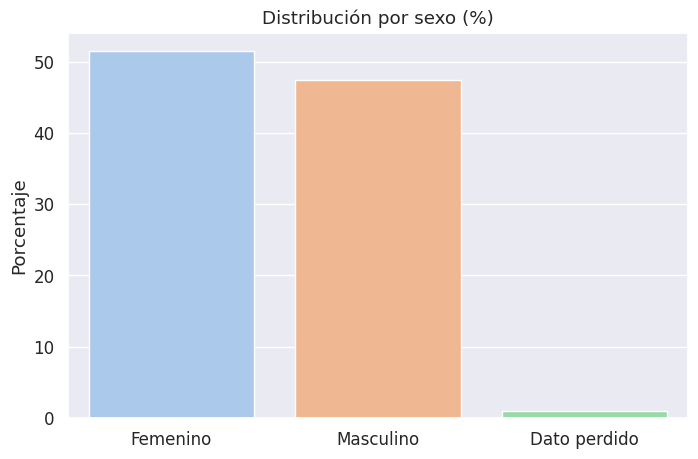

/tmp/ipython-input-1266514401.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=edad_counts.index, y=edad_counts.values, palette="crest")


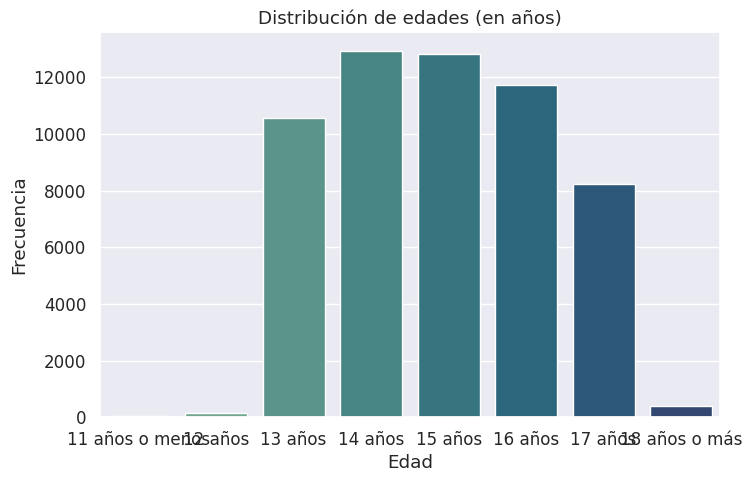

/tmp/ipython-input-1266514401.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=edu_counts.index, x=edu_counts.values, palette="flare")


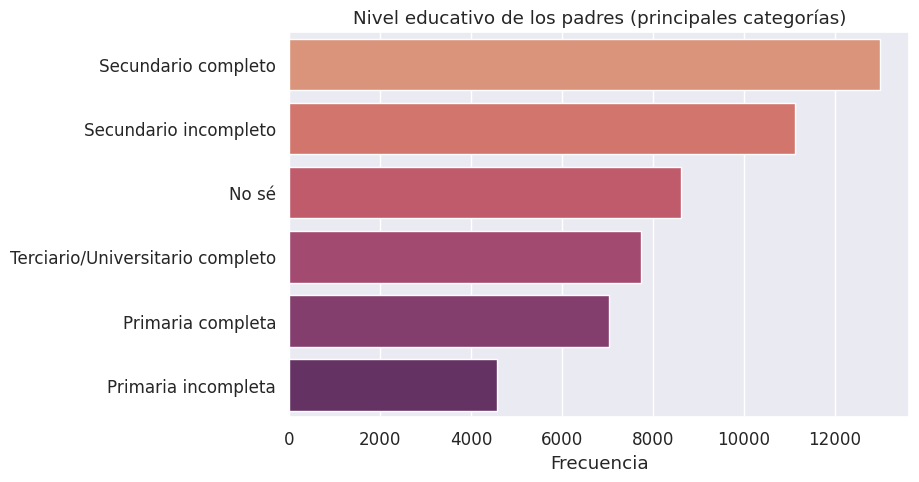

/tmp/ipython-input-1266514401.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_analisis, y='Actividad_fisica', order=df_analisis['Actividad_fisica'].value_counts().index, ax=axes[0], palette="Blues_r")
/tmp/ipython-input-1266514401.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_analisis, y='Consumo_frutas', order=df_analisis['Consumo_frutas'].value_counts().index, ax=axes[1], palette="Greens_r")


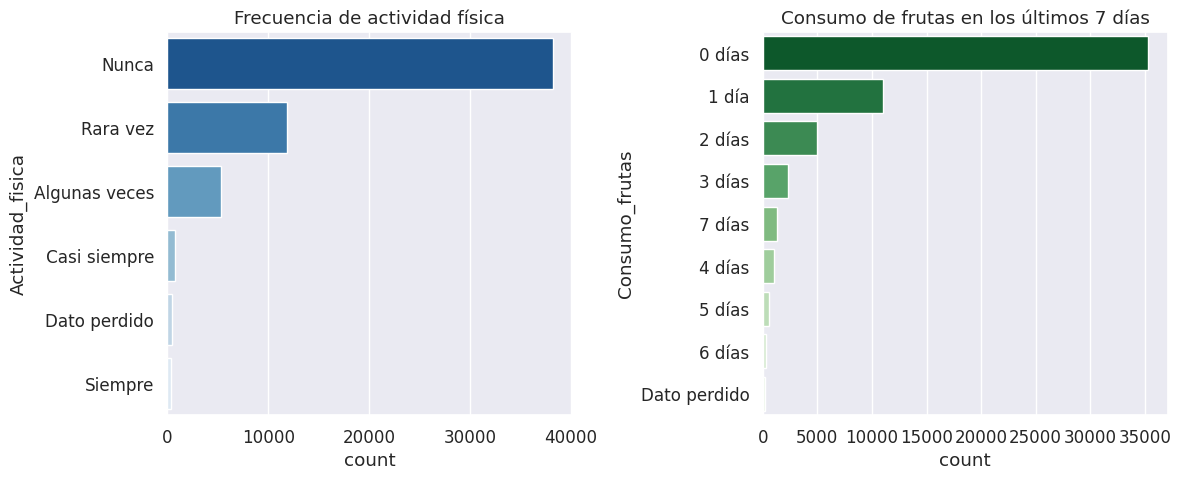

/tmp/ipython-input-1266514401.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_analisis, y='Tabaco', order=df_analisis['Tabaco'].value_counts().index, ax=axes[0], palette="Reds_r")
/tmp/ipython-input-1266514401.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_analisis, y='Alcohol', order=df_analisis['Alcohol'].value_counts().index, ax=axes[1], palette="Oranges_r")


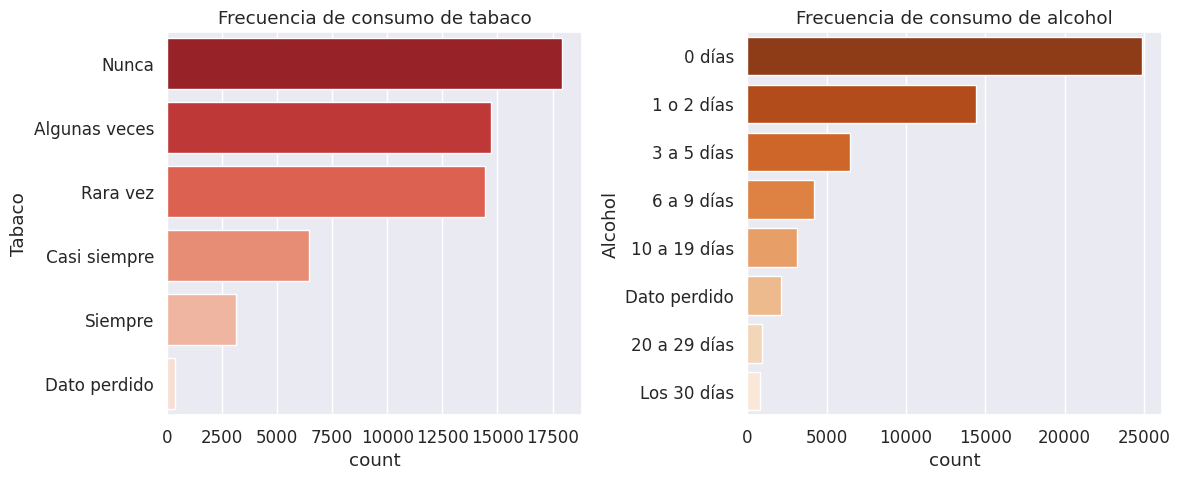

In [23]:
# ============================================
# BLOQUE: Estadística descriptiva y gráficos
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

# Configuración general
plt.style.use('seaborn-v0_8-whitegrid')
sns.set(font_scale=1.1)
plt.rcParams['figure.figsize'] = (8, 5)

# 1. Estadística descriptiva básica
print("Resumen general de las variables categóricas:\n")
for col in df_analisis.columns:
    print(f"{col}: {df_analisis[col].nunique()} categorías | {df_analisis[col].isna().mean():.1%} valores faltantes")
    print("Moda:", df_analisis[col].mode().values[0])
    print("-" * 50)

# 2. Distribución por sexo
sexo_counts = df_analisis['Sexo'].value_counts(normalize=True) * 100
sns.barplot(x=sexo_counts.index, y=sexo_counts.values, palette="pastel")
plt.title("Distribución por sexo (%)")
plt.ylabel("Porcentaje")
plt.xlabel("")
plt.show()

# 3. Distribución de edad
edad_counts = df_analisis['Edad'].value_counts().sort_index()
sns.barplot(x=edad_counts.index, y=edad_counts.values, palette="crest")
plt.title("Distribución de edades (en años)")
plt.ylabel("Frecuencia")
plt.xlabel("Edad")
plt.show()

# 4. Nivel educativo de los padres
edu_counts = df_analisis['Educacion_padres'].value_counts().head(6)
sns.barplot(y=edu_counts.index, x=edu_counts.values, palette="flare")
plt.title("Nivel educativo de los padres (principales categorías)")
plt.xlabel("Frecuencia")
plt.ylabel("")
plt.show()

# 5. Hábitos de salud (actividad física y consumo de frutas)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df_analisis, y='Actividad_fisica', order=df_analisis['Actividad_fisica'].value_counts().index, ax=axes[0], palette="Blues_r")
axes[0].set_title("Frecuencia de actividad física")

sns.countplot(data=df_analisis, y='Consumo_frutas', order=df_analisis['Consumo_frutas'].value_counts().index, ax=axes[1], palette="Greens_r")
axes[1].set_title("Consumo de frutas en los últimos 7 días")

plt.tight_layout()
plt.show()

# 6. Conductas de riesgo (tabaco y alcohol)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df_analisis, y='Tabaco', order=df_analisis['Tabaco'].value_counts().index, ax=axes[0], palette="Reds_r")
axes[0].set_title("Frecuencia de consumo de tabaco")

sns.countplot(data=df_analisis, y='Alcohol', order=df_analisis['Alcohol'].value_counts().index, ax=axes[1], palette="Oranges_r")
axes[1].set_title("Frecuencia de consumo de alcohol")

plt.tight_layout()
plt.show()

# ============================================
# FIN DEL BLOQUE
# ============================================

/tmp/ipython-input-4281507904.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


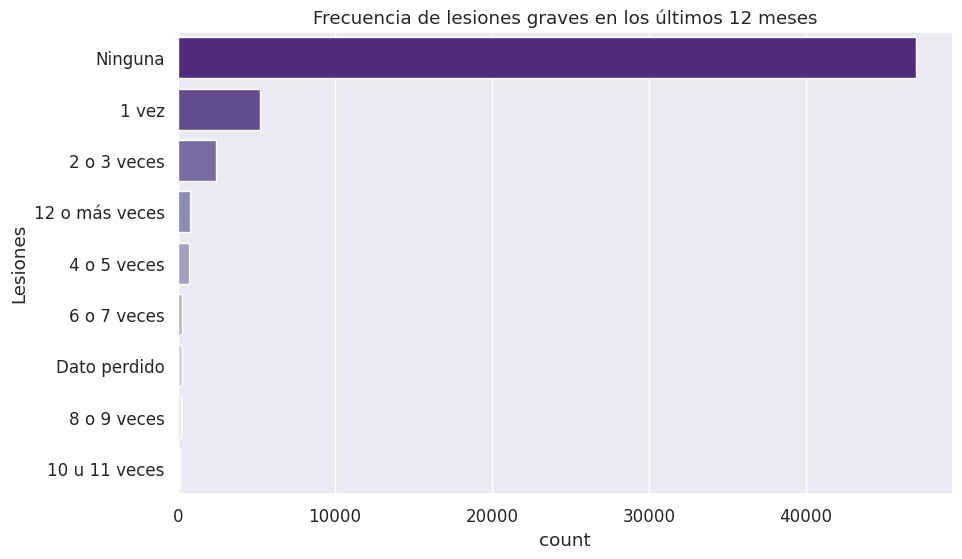

In [24]:
# -----------------------------------------------------------
# Frecuencia de lesiones graves en los últimos 12 meses
# -----------------------------------------------------------
plt.figure(figsize=(10,6))
sns.countplot(
    data=df_analisis,
    y='Lesiones',
    order=df_analisis['Lesiones'].value_counts().index,
    palette="Purples_r"
)
plt.title("Frecuencia de lesiones graves en los últimos 12 meses")
plt.xlabel("count")
plt.ylabel("Lesiones")
plt.show()

/tmp/ipython-input-2218756282.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


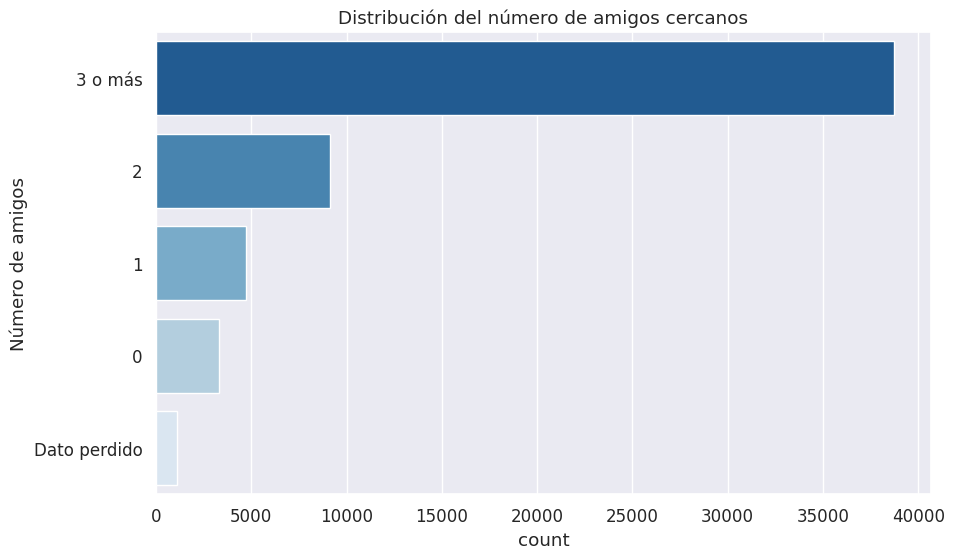

In [25]:
# -----------------------------------------------------------
# Frecuencia de amigos cercanos (factor de protección)
# -----------------------------------------------------------
plt.figure(figsize=(10,6))
sns.countplot(
    data=df_analisis,
    y='Amigos_cercanos',
    order=df_analisis['Amigos_cercanos'].value_counts().index,
    palette="Blues_r"
)
plt.title("Distribución del número de amigos cercanos")
plt.xlabel("count")
plt.ylabel("Número de amigos")
plt.show()

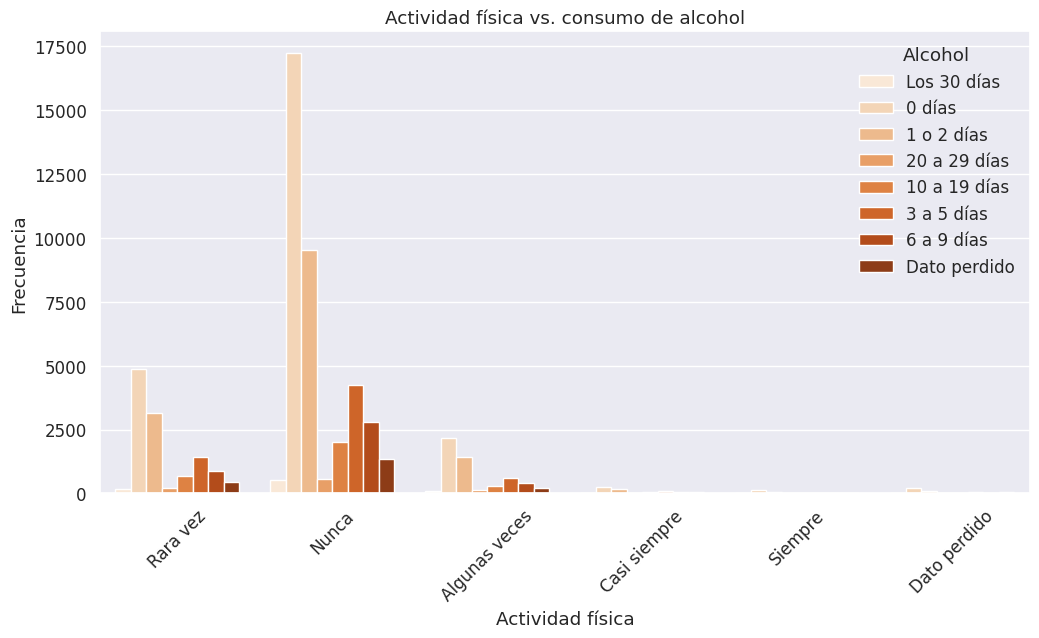

In [26]:
# -----------------------------------------------------------
# Cruce entre actividad física y consumo de alcohol
# -----------------------------------------------------------
plt.figure(figsize=(12,6))
sns.countplot(
    data=df_analisis,
    x='Actividad_fisica',
    hue='Alcohol',
    palette="Oranges"
)
plt.title("Actividad física vs. consumo de alcohol")
plt.xlabel("Actividad física")
plt.ylabel("Frecuencia")
plt.legend(title="Alcohol")
plt.xticks(rotation=45)
plt.show()

In [27]:
# ============================================
# EXPORTAR EL DICCIONARIO FINAL DE VARIABLES
# ============================================

diccionario_final.to_excel("diccionario_emse_2018_limpio.xlsx", index=False)
diccionario_final.to_csv("diccionario_emse_2018_limpio.csv", index=False)

print("Diccionario de variables exportado correctamente.")

diccionario_final = codigos_filtrado[codigos_filtrado["Variable"].isin(vars_existentes)].reset_index(drop=True)
display(diccionario_final.head(30))

Diccionario de variables exportado correctamente.


,Variable,Descripcion
0,record,Nº de registro
1,q1,¿Qué edad tienes?
2,q2,¿Cuál es tu sexo?
3,q3,¿En qué grado o año estás?
4,q4,"¿Cuál es tu estatura, sin zapatos? (Nota: dato..."
5,q5,"¿Cuánto pesas, sin zapatos? (Nota: dato en ki..."
6,q6,Durante los últimos 30 días ¿con qué frecuenci...
7,q10,"Durante los últimos 7 días, ¿cuántos días comi..."
8,q15,"Durante los últimos 12 meses, Cuantas veces fu..."
9,q16,"Durante los últimos 12 meses, ¿cuántas veces p..."


In [28]:
# 3. Mostrar un resumen de las variables activas
print(f"\nDiccionario final de variables activas: {diccionario_final.shape[0]} variables encontradas\n")
display(diccionario_final.head(15))

# >>> AGREGA AQUÍ EL EXPORTADOR <<<
diccionario_final.to_excel("diccionario_emse_2018_limpio.xlsx", index=False)
diccionario_final.to_csv("diccionario_emse_2018_limpio.csv", index=False)
print("Diccionario de variables exportado correctamente.")


Diccionario final de variables activas: 157 variables encontradas



,Variable,Descripcion
0,record,Nº de registro
1,q1,¿Qué edad tienes?
2,q2,¿Cuál es tu sexo?
3,q3,¿En qué grado o año estás?
4,q4,"¿Cuál es tu estatura, sin zapatos? (Nota: dato..."
5,q5,"¿Cuánto pesas, sin zapatos? (Nota: dato en ki..."
6,q6,Durante los últimos 30 días ¿con qué frecuenci...
7,q10,"Durante los últimos 7 días, ¿cuántos días comi..."
8,q15,"Durante los últimos 12 meses, Cuantas veces fu..."
9,q16,"Durante los últimos 12 meses, ¿cuántas veces p..."


Diccionario de variables exportado correctamente.


In [29]:
# ============================================================
# EXPORTAR SUBCONJUNTO ANALÍTICO LIMPIO PARA FUTURO MODELADO
# ============================================================

df_analisis.to_csv("EMSE_2018_subconjunto_analitico.csv", index=False, encoding="utf-8")
df_analisis.to_excel("EMSE_2018_subconjunto_analitico.xlsx", index=False)

print("Subconjunto analítico exportado correctamente.")

df_analisis = sub_df[cols_textuales].copy()
df_analisis.head()

Subconjunto analítico exportado correctamente.


,Edad,Sexo,Grado,Actividad_fisica,Consumo_frutas,Lesiones,Tabaco,Amigos_cercanos,Alcohol,Educacion_padres
0,13 años,Femenino,9no grado nivel Primario/Polimodal o 2do año n...,Rara vez,0 días,Ninguna,Siempre,2,Los 30 días,Terciario/Universitario completo
1,13 años,Femenino,9no grado nivel Primario/Polimodal o 2do año n...,Nunca,0 días,Ninguna,Nunca,3 o más,0 días,Secundario incompleto
2,14 años,Masculino,2do año/11vo grado nivel Polimodal o 4to año n...,Nunca,0 días,Ninguna,Nunca,3 o más,0 días,Secundario completo
3,16 años,Masculino,9no grado nivel Primario/Polimodal o 2do año n...,Nunca,3 días,Ninguna,Nunca,3 o más,1 o 2 días,Secundario incompleto
4,13 años,Femenino,9no grado nivel Primario/Polimodal o 2do año n...,Nunca,0 días,Ninguna,Rara vez,3 o más,0 días,Primaria completa


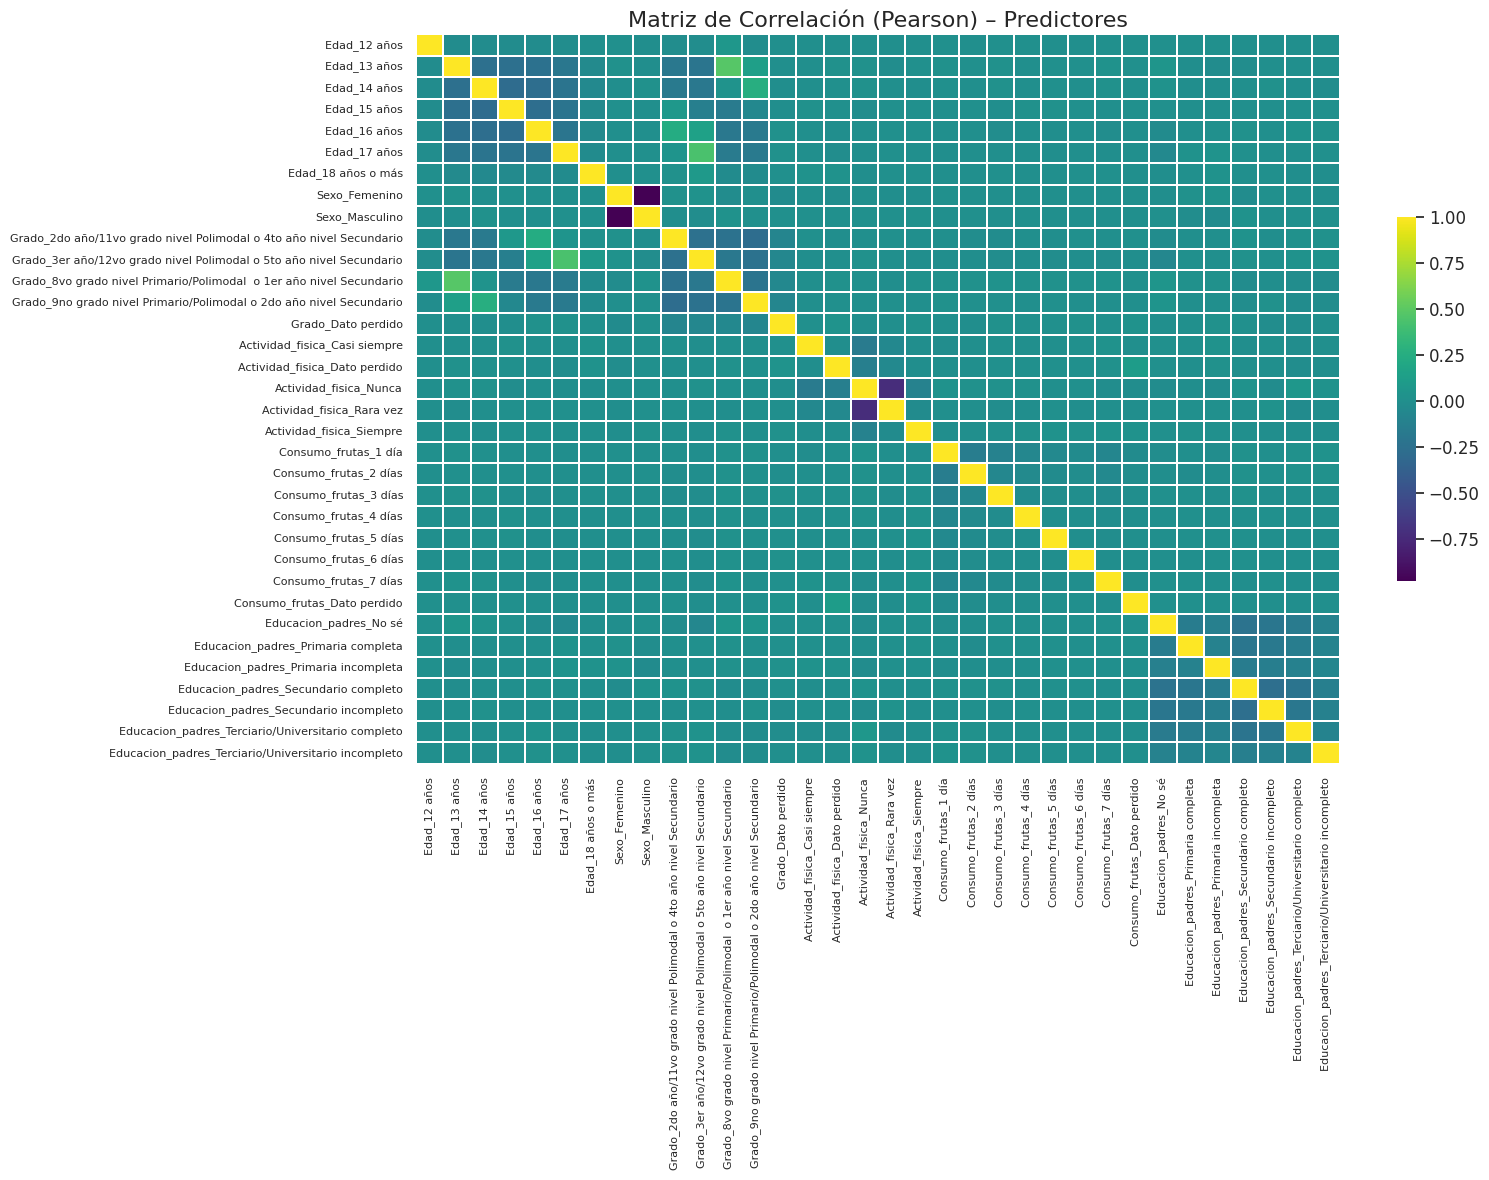

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

# ===================================
# MATRIZ DE CORRELACIÓN PEARSON
# ===================================
plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_pearson,
    cmap="viridis",
    annot=False,
    square=False,
    linewidths=.3,
    cbar_kws={"shrink": .5}
)

plt.title("Matriz de Correlación (Pearson) – Predictores", fontsize=16)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

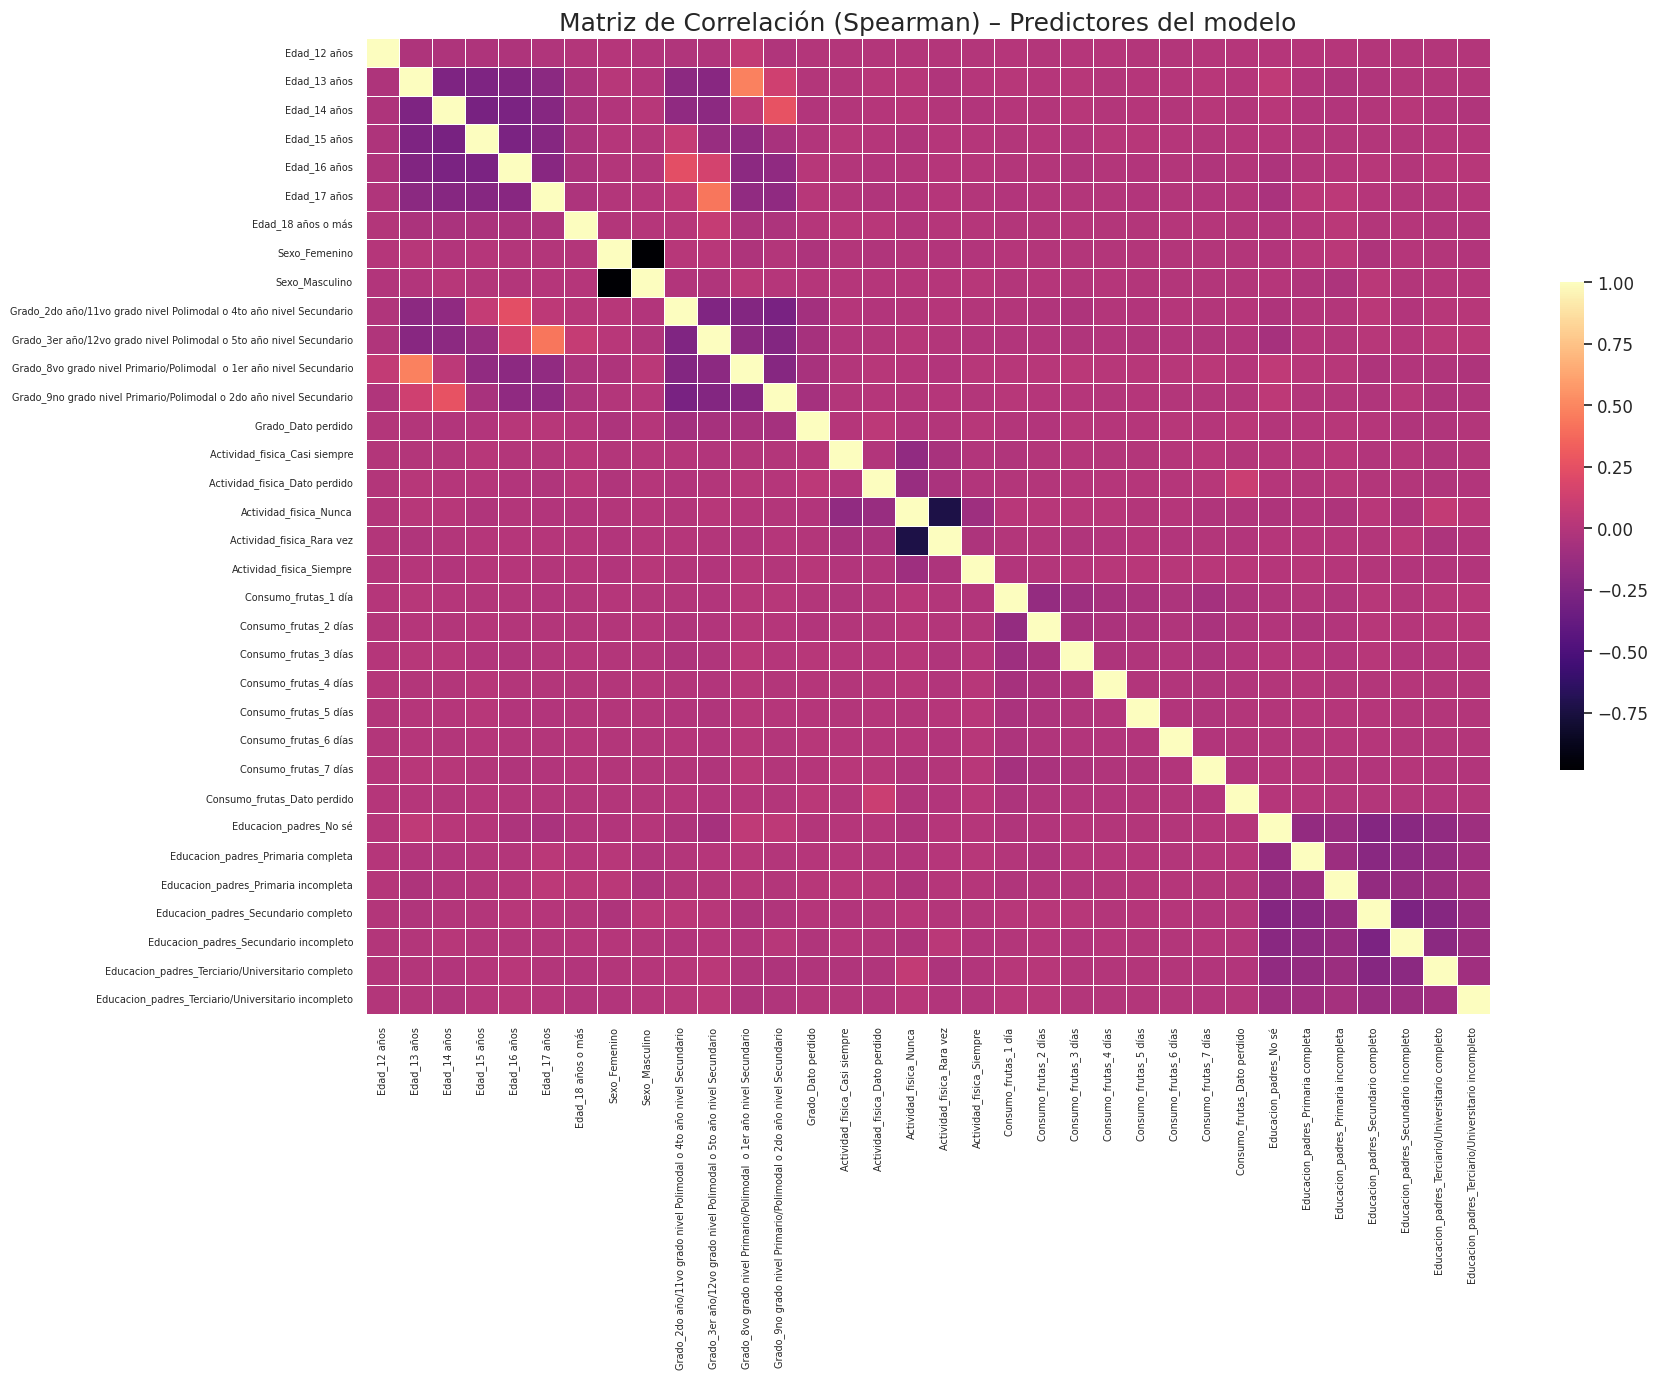

In [66]:
# ===================================
# MATRIZ DE CORRELACIÓN SPEARMAN (Optimizada)
# ===================================
corr_spearman = X_train2.corr(method="spearman")

plt.figure(figsize=(18, 14))   # Más grande para muchas variables
sns.heatmap(
    corr_spearman,
    cmap="magma",
    annot=False,
    square=False,              # square=True deforma el plot cuando hay muchas variables
    linewidths=.4,
    cbar_kws={"shrink": 0.5}   # barra de color más compacta
)

plt.title("Matriz de Correlación (Spearman) – Predictores del modelo", fontsize=18)

# === Ajuste de etiquetas ===
plt.xticks(rotation=90, fontsize=7)   # rotación adecuada + tamaño reducido
plt.yticks(rotation=0, fontsize=7)

plt.tight_layout()
plt.show()

In [30]:
# ============================================================
# SCORE Y VARIABLE DE RIESGO CRÍTICO ADOLESCENTE (OPS/OMS)
# ============================================================

# Copia del dataset limpio usado en los análisis previos
df_modelo = df_analisis.copy()

# ------------------------------------------------------------
# 1. Factores críticos individuales de riesgo
# ------------------------------------------------------------

# Consumo de alcohol: riesgo si ≠ "0 días"
riesgo_alcohol = (df_modelo["Alcohol"] != "0 días").astype(int)

# Consumo de tabaco: riesgo si ≠ "Nunca"
riesgo_tabaco = (df_modelo["Tabaco"] != "Nunca").astype(int)

# Lesiones graves: solo moderada/grave/muy grave
lesiones_graves = df_modelo["Lesiones"].isin([
    "Moderada", "Grave", "Muy grave"
]).astype(int)

# Bajo apoyo social severo: solo "0 amigos"
bajo_apoyo_severo = (df_modelo["Amigos_cercanos"] == "0").astype(int)

# ------------------------------------------------------------
# 2. Construcción del SCORE (0 a 4)
# ------------------------------------------------------------
df_modelo["Score_riesgo"] = (
    riesgo_alcohol +
    riesgo_tabaco +
    lesiones_graves +
    bajo_apoyo_severo
)

print("Distribución del Score de Riesgo (0–4):")
display(df_modelo["Score_riesgo"].value_counts(normalize=True).sort_index() * 100)

# ------------------------------------------------------------
# 3. Clasificación en categorías epidemiológicas
# ------------------------------------------------------------
df_modelo["Riesgo_cat"] = pd.cut(
    df_modelo["Score_riesgo"],
    bins=[-0.1, 0, 1, 4],
    labels=["Sin riesgo", "Riesgo moderado", "Riesgo alto"]
)

print("\nDistribución de las categorías de riesgo:")
display(df_modelo["Riesgo_cat"].value_counts(normalize=True) * 100)

# ------------------------------------------------------------
# 4. Variable binaria para el modelo (riesgo ALTO)
#    Riesgo_global = 1 si Score_riesgo >= 2
# ------------------------------------------------------------
df_modelo["Riesgo_global"] = (df_modelo["Score_riesgo"] >= 2).astype(int)

print("\nProporción de Riesgo Global (binario):")
display(df_modelo["Riesgo_global"].value_counts(normalize=True) * 100)

# ------------------------------------------------------------
# 5. Vista rápida de los primeros registros
# ------------------------------------------------------------
df_modelo.head()

Distribución del Score de Riesgo (0–4):


,proportion
Score_riesgo,
0,15.947421
1,39.553535
2,42.301820
3,2.197224



Distribución de las categorías de riesgo:


,proportion
Riesgo_cat,
Riesgo alto,44.499044
Riesgo moderado,39.553535
Sin riesgo,15.947421



Proporción de Riesgo Global (binario):


,proportion
Riesgo_global,
0,55.500956
1,44.499044


,Edad,Sexo,Grado,Actividad_fisica,Consumo_frutas,Lesiones,Tabaco,Amigos_cercanos,Alcohol,Educacion_padres,Score_riesgo,Riesgo_cat,Riesgo_global
0,13 años,Femenino,9no grado nivel Primario/Polimodal o 2do año n...,Rara vez,0 días,Ninguna,Siempre,2,Los 30 días,Terciario/Universitario completo,2,Riesgo alto,1
1,13 años,Femenino,9no grado nivel Primario/Polimodal o 2do año n...,Nunca,0 días,Ninguna,Nunca,3 o más,0 días,Secundario incompleto,0,Sin riesgo,0
2,14 años,Masculino,2do año/11vo grado nivel Polimodal o 4to año n...,Nunca,0 días,Ninguna,Nunca,3 o más,0 días,Secundario completo,0,Sin riesgo,0
3,16 años,Masculino,9no grado nivel Primario/Polimodal o 2do año n...,Nunca,3 días,Ninguna,Nunca,3 o más,1 o 2 días,Secundario incompleto,1,Riesgo moderado,0
4,13 años,Femenino,9no grado nivel Primario/Polimodal o 2do año n...,Nunca,0 días,Ninguna,Rara vez,3 o más,0 días,Primaria completa,1,Riesgo moderado,0


In [31]:
print("""
============================================================
CONSTRUCCIÓN DEL SCORE DE RIESGO CRÍTICO ADOLESCENTE (OPS/OMS)
============================================================

El Score de Riesgo Crítico se construyó integrando cuatro
factores priorizados por organismos internacionales de salud
(OPS/OMS) como indicadores de vulnerabilidad adolescente:

  1. Consumo de alcohol en los últimos 30 días.
  2. Consumo de tabaco.
  3. Presencia de lesiones graves (moderada, grave, muy grave).
  4. Bajo apoyo social severo (0 amigos cercanos).

A cada estudiante se le asigna 1 punto por cada factor presente.
El resultado es un Score entre 0 y 4 que refleja el grado de
acumulación de factores de riesgo.

Interpretación del Score:
  - 0 puntos  → Sin riesgo crítico.
  - 1 punto   → Exposición leve.
  - 2 puntos  → Acumulación significativa de riesgo.
  - 3-4 puntos → Vulnerabilidad severa.

============================================================
CLASIFICACIÓN EPIDEMIOLÓGICA DE RIESGO
============================================================

A partir del Score se definieron tres categorías:

  • Sin riesgo       → Score = 0
  • Riesgo moderado  → Score = 1
  • Riesgo alto      → Score ≥ 2

Esta clasificación se fundamenta en la evidencia de que la
coexistencia de dos o más factores críticos eleva de manera
no lineal la probabilidad de daño físico, psicológico y social.

============================================================
VARIABLE BINARIA PARA EL MODELO (Riesgo_global)
============================================================

Para el modelo predictivo, se definió la variable Riesgo_global:

  Riesgo_global = 1   si Score_riesgo ≥ 2  (riesgo alto)
  Riesgo_global = 0   si Score_riesgo < 2  (sin riesgo crítico)

Esto permite entrenar modelos estadísticos orientados a identificar
los principales predictores de riesgo crítico en la población escolar.

============================================================
""")


CONSTRUCCIÓN DEL SCORE DE RIESGO CRÍTICO ADOLESCENTE (OPS/OMS)

El Score de Riesgo Crítico se construyó integrando cuatro 
factores priorizados por organismos internacionales de salud 
(OPS/OMS) como indicadores de vulnerabilidad adolescente:

  1. Consumo de alcohol en los últimos 30 días.
  2. Consumo de tabaco.
  3. Presencia de lesiones graves (moderada, grave, muy grave).
  4. Bajo apoyo social severo (0 amigos cercanos).

A cada estudiante se le asigna 1 punto por cada factor presente.
El resultado es un Score entre 0 y 4 que refleja el grado de 
acumulación de factores de riesgo.

Interpretación del Score:
  - 0 puntos  → Sin riesgo crítico.
  - 1 punto   → Exposición leve.
  - 2 puntos  → Acumulación significativa de riesgo.
  - 3-4 puntos → Vulnerabilidad severa.

CLASIFICACIÓN EPIDEMIOLÓGICA DE RIESGO

A partir del Score se definieron tres categorías:

  • Sin riesgo       → Score = 0
  • Riesgo moderado  → Score = 1
  • Riesgo alto      → Score ≥ 2

Esta clasificación se fu

In [32]:
# ============================================================
# PREPARACIÓN DE VARIABLES PARA EL MODELO LOGIT
# ============================================================

# Variable objetivo
y = df_modelo["Riesgo_global"]

# Variables predictoras (todas menos la variable objetivo y el score categórico)
X_raw = df_modelo.drop(columns=["Riesgo_global", "Riesgo_cat", "Score_riesgo"])

# One-hot encoding
X = pd.get_dummies(X_raw, drop_first=True)


print("Dimensiones del dataset final para modelado:")
print("X:", X.shape, " | y:", y.shape)

Dimensiones del dataset final para modelado:
X: (56981, 58)  | y: (56981,)


In [33]:
# 2. Train/Test Split (70/30)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print("Train:", X_train.shape, " | Test:", X_test.shape)

Train: (39886, 58)  | Test: (17095, 58)


In [35]:
# Convertir todo X y y a float

# Convertir todo X y y a float (para sklearn)
X_train = X_train.astype(float)
X_test = X_test.astype(float)
y_train = y_train.astype(float)
y_test = y_test.astype(float)

print("Conversión a float completa.")

Conversión a float completa.


Columnas eliminadas: ['Lesiones_10 u 11 veces', 'Lesiones_12 o más veces', 'Lesiones_2 o 3 veces', 'Lesiones_4 o 5 veces', 'Lesiones_6 o 7 veces', 'Lesiones_8 o 9 veces', 'Lesiones_Dato perdido', 'Lesiones_Ninguna', 'Tabaco_Casi siempre', 'Tabaco_Dato perdido', 'Tabaco_Nunca', 'Tabaco_Rara vez', 'Tabaco_Siempre', 'Amigos_cercanos_1', 'Amigos_cercanos_2', 'Amigos_cercanos_3 o más', 'Amigos_cercanos_Dato perdido', 'Alcohol_1 o 2 días', 'Alcohol_10 a 19 días', 'Alcohol_20 a 29 días', 'Alcohol_3 a 5 días', 'Alcohol_6 a 9 días', 'Alcohol_Dato perdido', 'Alcohol_Los 30 días']

Accuracy: 0.6222287218484938

Matriz de confusión:
[[6876 2612]
 [3846 3761]]

AUC: 0.6629008633656184


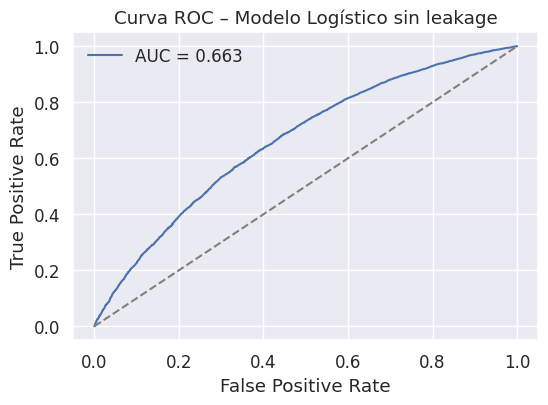

,Variable,Coeficiente
5,Edad_17 años,0.486516
6,Edad_18 años o más,0.484745
4,Edad_16 años,0.348598
14,Actividad_fisica_Casi siempre,0.328373
24,Consumo_frutas_6 días,0.317654
22,Consumo_frutas_4 días,0.270476
23,Consumo_frutas_5 días,0.248231
25,Consumo_frutas_7 días,0.240094
20,Consumo_frutas_2 días,0.235795
21,Consumo_frutas_3 días,0.229914


In [36]:
# ============================================================
# Eliminación de predictores que definen directamente el riesgo
# ============================================================

# Identificar columnas a excluir
cols_to_drop = [
    c for c in X.columns
    if c.startswith("Alcohol")
    or c.startswith("Tabaco")
    or c.startswith("Lesiones")
    or c.startswith("Amigos_cercanos")
]

print("Columnas eliminadas:", cols_to_drop)

# Crear nuevo dataset sin leakage
X_clean = X.drop(columns=cols_to_drop)

# Nuevo train/test split
from sklearn.model_selection import train_test_split

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_clean, y, test_size=0.30, random_state=42, stratify=y
)

# ============================================================
# Modelo Logístico (sklearn) sin leakage
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import pandas as pd

model2 = LogisticRegression(max_iter=3000, solver="lbfgs")

# Entrenar
model2.fit(X_train2, y_train2)

# Predicciones
y_pred2 = model2.predict(X_test2)
y_prob2 = model2.predict_proba(X_test2)[:, 1]

# Métricas
print("\nAccuracy:", accuracy_score(y_test2, y_pred2))
print("\nMatriz de confusión:")
print(confusion_matrix(y_test2, y_pred2))
print("\nAUC:", roc_auc_score(y_test2, y_prob2))

# Curva ROC
fpr, tpr, _ = roc_curve(y_test2, y_prob2)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test2, y_prob2):.3f}")
plt.plot([0,1], [0,1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC – Modelo Logístico sin leakage")
plt.legend()
plt.show()

# Coeficientes del modelo
coef_df2 = pd.DataFrame({
    "Variable": X_train2.columns,
    "Coeficiente": model2.coef_[0]
}).sort_values(by="Coeficiente", ascending=False)

coef_df2.head(20)

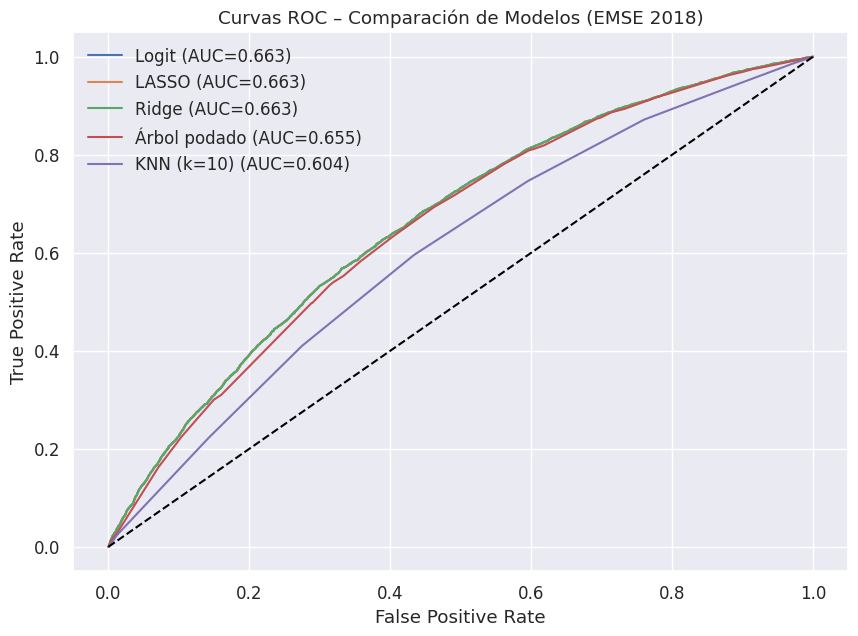

In [37]:
# Comparación de modelos

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt
import numpy as np

modelos = {
    "Logit": LogisticRegression(max_iter=3000, solver="lbfgs"),
    "LASSO": LogisticRegression(max_iter=3000, penalty="l1", solver="liblinear"),
    "Ridge": LogisticRegression(max_iter=3000, penalty="l2"),
    "Árbol podado": DecisionTreeClassifier(max_depth=6),
    "KNN (k=10)": Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=10))
    ]),
}

plt.figure(figsize=(10,7))

for nombre, modelo in modelos.items():
    modelo.fit(X_train2, y_train2)
    probs = modelo.predict_proba(X_test2)[:, 1]

    fpr, tpr, _ = roc_curve(y_test2, probs)
    auc = roc_auc_score(y_test2, probs)

    plt.plot(fpr, tpr, label=f"{nombre} (AUC={auc:.3f})")

# Línea base
plt.plot([0,1], [0,1], '--', color='black')

plt.title("Curvas ROC – Comparación de Modelos (EMSE 2018)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

In [38]:
!pip install xgboost

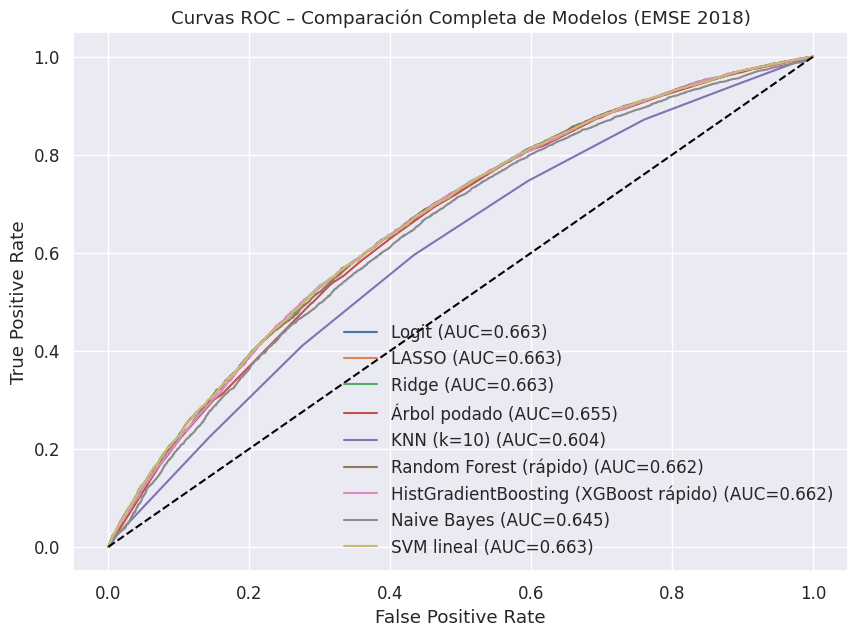

In [39]:
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

# ============================================================
# Modelos adicionales optimizados
# ============================================================

modelos_extra = {

    "Random Forest (rápido)": RandomForestClassifier(
        n_estimators=120,
        max_depth=8,
        max_features="sqrt",
        n_jobs=-1,
        random_state=42
    ),

    "HistGradientBoosting (XGBoost rápido)": HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_depth=6,
        max_iter=300,
        random_state=42
    ),

    "Naive Bayes": GaussianNB(),

    # SVM lineal calibrado (versión sklearn nueva usa 'estimator=')
    "SVM lineal": CalibratedClassifierCV(
        estimator=LinearSVC(C=1.0, random_state=42),
        cv=5
    )
}

# ============================================================
# Graficar ROC de TODOS los modelos
# ============================================================

plt.figure(figsize=(10,7))

# Modelos previos
for nombre, modelo in modelos.items():
    modelo.fit(X_train2, y_train2)
    probs = modelo.predict_proba(X_test2)[:, 1]
    auc = roc_auc_score(y_test2, probs)
    fpr, tpr, _ = roc_curve(y_test2, probs)
    plt.plot(fpr, tpr, label=f"{nombre} (AUC={auc:.3f})")

# Modelos nuevos
for nombre, modelo in modelos_extra.items():
    modelo.fit(X_train2, y_train2)

    # predict_proba funciona en todos los calibrados correctamente
    probs = modelo.predict_proba(X_test2)[:, 1]

    auc = roc_auc_score(y_test2, probs)
    fpr, tpr, _ = roc_curve(y_test2, probs)
    plt.plot(fpr, tpr, label=f"{nombre} (AUC={auc:.3f})")

plt.plot([0,1], [0,1], '--', color="black")

plt.title("Curvas ROC – Comparación Completa de Modelos (EMSE 2018)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

In [40]:
# Ranking de Modelos (AUC + métricas completas)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd
import time

resultados = []

# Unimos los diccionarios
todos_los_modelos = {**modelos, **modelos_extra}

for nombre, modelo in todos_los_modelos.items():

    print(f"\nEntrenando modelo: {nombre}")
    inicio = time.time()

    # Ajustar modelo
    modelo.fit(X_train2, y_train2)

    # Obtener probabilidades
    if hasattr(modelo, "predict_proba"):
        probs = modelo.predict_proba(X_test2)[:, 1]
    else:  # Para SVM lineal calibrado o métodos sin predict_proba
        probs = modelo.decision_function(X_test2)

    # Predicción binaria
    y_pred = modelo.predict(X_test2)

    # Métricas
    auc = roc_auc_score(y_test2, probs)
    acc = accuracy_score(y_test2, y_pred)
    prec = precision_score(y_test2, y_pred)
    rec = recall_score(y_test2, y_pred)
    f1 = f1_score(y_test2, y_pred)

    fin = time.time()
    duracion = fin - inicio

    resultados.append([
        nombre, auc, acc, prec, rec, f1, duracion
    ])

# Tabla ordenada por AUC
ranking_df = pd.DataFrame(resultados, columns=[
    "Modelo", "AUC", "Accuracy", "Precision", "Recall", "F1-score", "Tiempo (s)"
]).sort_values(by="AUC", ascending=False)

ranking_df


Entrenando modelo: Logit

Entrenando modelo: LASSO

Entrenando modelo: Ridge

Entrenando modelo: Árbol podado

Entrenando modelo: KNN (k=10)

Entrenando modelo: Random Forest (rápido)

Entrenando modelo: HistGradientBoosting (XGBoost rápido)

Entrenando modelo: Naive Bayes

Entrenando modelo: SVM lineal


,Modelo,AUC,Accuracy,Precision,Recall,F1-score,Tiempo (s)
1,LASSO,0.662928,0.623984,0.591268,0.502038,0.543012,2.781868
0,Logit,0.662901,0.622229,0.590146,0.494413,0.538054,0.906724
2,Ridge,0.662901,0.622229,0.590146,0.494413,0.538054,1.323062
8,SVM lineal,0.662862,0.623106,0.591165,0.496122,0.539490,0.765580
5,Random Forest (rápido),0.662001,0.619947,0.584759,0.503352,0.541010,3.756224
6,HistGradientBoosting (XGBoost rápido),0.661603,0.624276,0.584330,0.539240,0.560881,1.692916
3,Árbol podado,0.655043,0.618192,0.575843,0.538977,0.556800,0.374344
7,Naive Bayes,0.644804,0.608073,0.558238,0.571447,0.564765,0.069763
4,KNN (k=10),0.604457,0.584966,0.544708,0.410017,0.467862,27.866657


/tmp/ipython-input-3341701012.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


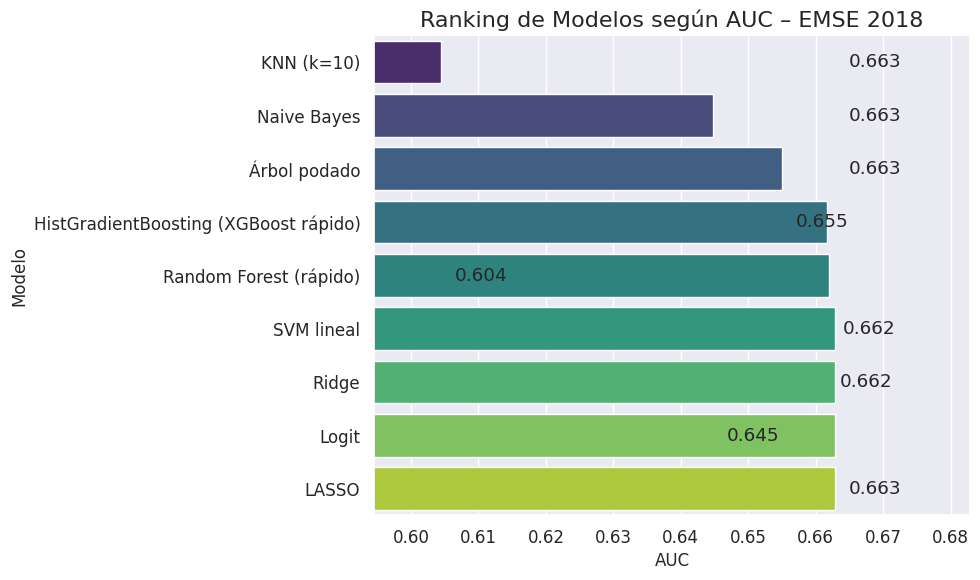

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ordenar por AUC (mayor a menor)
ranking_auc = ranking_df.sort_values(by="AUC", ascending=True)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=ranking_auc,
    x="AUC",
    y="Modelo",
    palette="viridis"
)

plt.title("Ranking de Modelos según AUC – EMSE 2018", fontsize=16)
plt.xlabel("AUC", fontsize=12)
plt.ylabel("Modelo", fontsize=12)

# Mostrar valores al lado de cada barra
for index, row in ranking_auc.iterrows():
    plt.text(row["AUC"] + 0.002, index, f"{row['AUC']:.3f}", va='center')

plt.xlim(ranking_auc["AUC"].min() - 0.01, ranking_auc["AUC"].max() + 0.02)
plt.tight_layout()
plt.show()

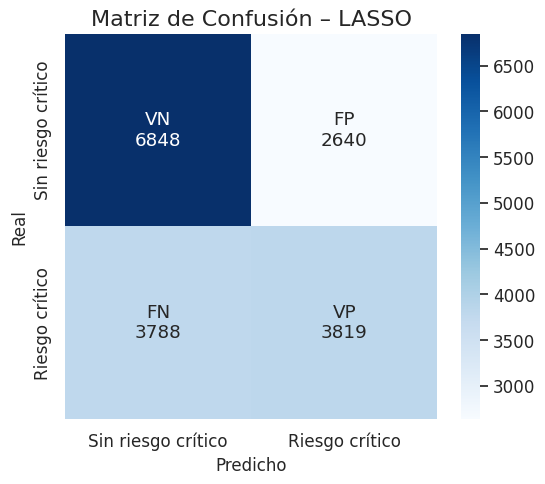

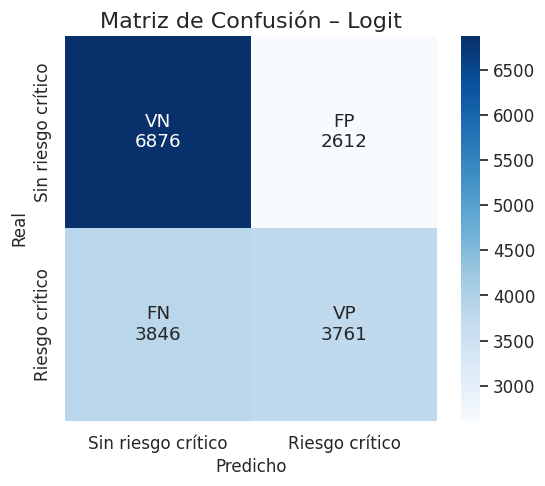

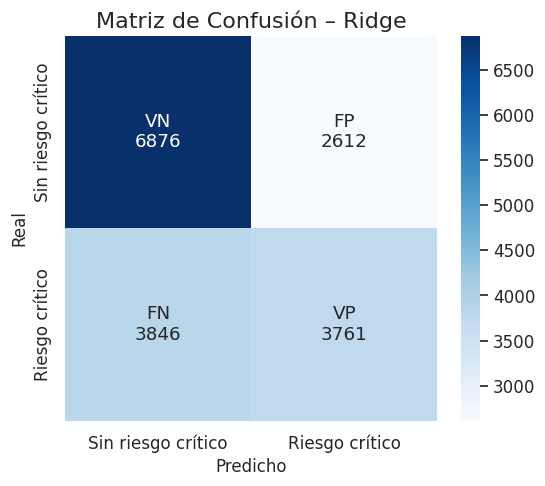

In [42]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

top3 = ranking_df.head(3)["Modelo"].values

for nombre in top3:
    modelo = todos_los_modelos[nombre]
    modelo.fit(X_train2, y_train2)
    y_pred = modelo.predict(X_test2)

    cm = confusion_matrix(y_test2, y_pred)

    # Extraer valores
    vn, fp, fn, vp = cm.ravel()

    # Crear anotaciones en español
    anotaciones = np.array([
        [f"VN\n{vn}", f"FP\n{fp}"],
        [f"FN\n{fn}", f"VP\n{vp}"]
    ])

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=anotaciones,
        fmt="",
        cmap="Blues",
        xticklabels=["Sin riesgo crítico", "Riesgo crítico"],
        yticklabels=["Sin riesgo crítico", "Riesgo crítico"],
        cbar=True
    )

    plt.title(f"Matriz de Confusión – {nombre}", fontsize=16)
    plt.xlabel("Predicho", fontsize=12)
    plt.ylabel("Real", fontsize=12)
    plt.show()

In [43]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3
)

gb.fit(X_train2, y_train2)

importancias_gb = pd.DataFrame({
    "Variable": X_train2.columns,
    "Importance_GB": gb.feature_importances_
}).sort_values(by="Importance_GB", ascending=False)

importancias_gb.head(15)

,Variable,Importance_GB
1,Edad_13 años,0.262316
8,Sexo_Masculino,0.183684
16,Actividad_fisica_Nunca,0.148009
2,Edad_14 años,0.103698
7,Sexo_Femenino,0.062615
5,Edad_17 años,0.038517
11,Grado_8vo grado nivel Primario/Polimodal o 1e...,0.037980
4,Edad_16 años,0.021523
10,Grado_3er año/12vo grado nivel Polimodal o 5to...,0.017838
31,Educacion_padres_Secundario incompleto,0.011798


In [44]:
from sklearn.inspection import permutation_importance

hgb = modelos_extra["HistGradientBoosting (XGBoost rápido)"]
hgb.fit(X_train2, y_train2)

result = permutation_importance(
    hgb,
    X_test2,
    y_test2,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importancias_hgb = pd.DataFrame({
    "Variable": X_train2.columns,
    "Importance_HGB": result.importances_mean
}).sort_values(by="Importance_HGB", ascending=False)

importancias_hgb.head(15)

,Variable,Importance_HGB
1,Edad_13 años,0.035706
16,Actividad_fisica_Nunca,0.019591
2,Edad_14 años,0.014355
8,Sexo_Masculino,0.013723
7,Sexo_Femenino,0.008295
11,Grado_8vo grado nivel Primario/Polimodal o 1e...,0.004276
5,Edad_17 años,0.001843
31,Educacion_padres_Secundario incompleto,0.001737
17,Actividad_fisica_Rara vez,0.001451
10,Grado_3er año/12vo grado nivel Polimodal o 5to...,0.001351


In [45]:
from sklearn.tree import DecisionTreeClassifier
import numpy as np

# Árbol base
arbol_base = DecisionTreeClassifier(random_state=42)
arbol_base.fit(X_train2, y_train2)

# Ruta de poda
path = arbol_base.cost_complexity_pruning_path(X_train2, y_train2)
ccp_alphas = path.ccp_alphas

# Filtrar y limpiar alphas
ccp_alphas = ccp_alphas[ccp_alphas >= 0]
ccp_alphas = np.unique(ccp_alphas)

print("Alphas totales:", len(ccp_alphas))

# ============================================
# 🔥 REDUCIR alphas a un número manejable (30)
# ============================================
if len(ccp_alphas) > 30:
    ccp_alphas = np.linspace(ccp_alphas.min(), ccp_alphas.max(), 30)

print("Alphas utilizados:", len(ccp_alphas))

# Entrenar árboles podados
arboles = []
for alpha in ccp_alphas:
    modelo = DecisionTreeClassifier(
        random_state=42,
        ccp_alpha=float(alpha)
    )
    modelo.fit(X_train2, y_train2)
    arboles.append(modelo)

# Evaluar
train_scores = [m.score(X_train2, y_train2) for m in arboles]
test_scores  = [m.score(X_test2, y_test2) for m in arboles]

indice_optimo = np.argmax(test_scores)
alpha_optimo = float(ccp_alphas[indice_optimo])

print("alpha_optimo =", alpha_optimo)
print("Accuracy test =", test_scores[indice_optimo])

Alphas totales: 2021
Alphas utilizados: 30
alpha_optimo = 0.00045671613640345436
Accuracy test = 0.6173150043872477


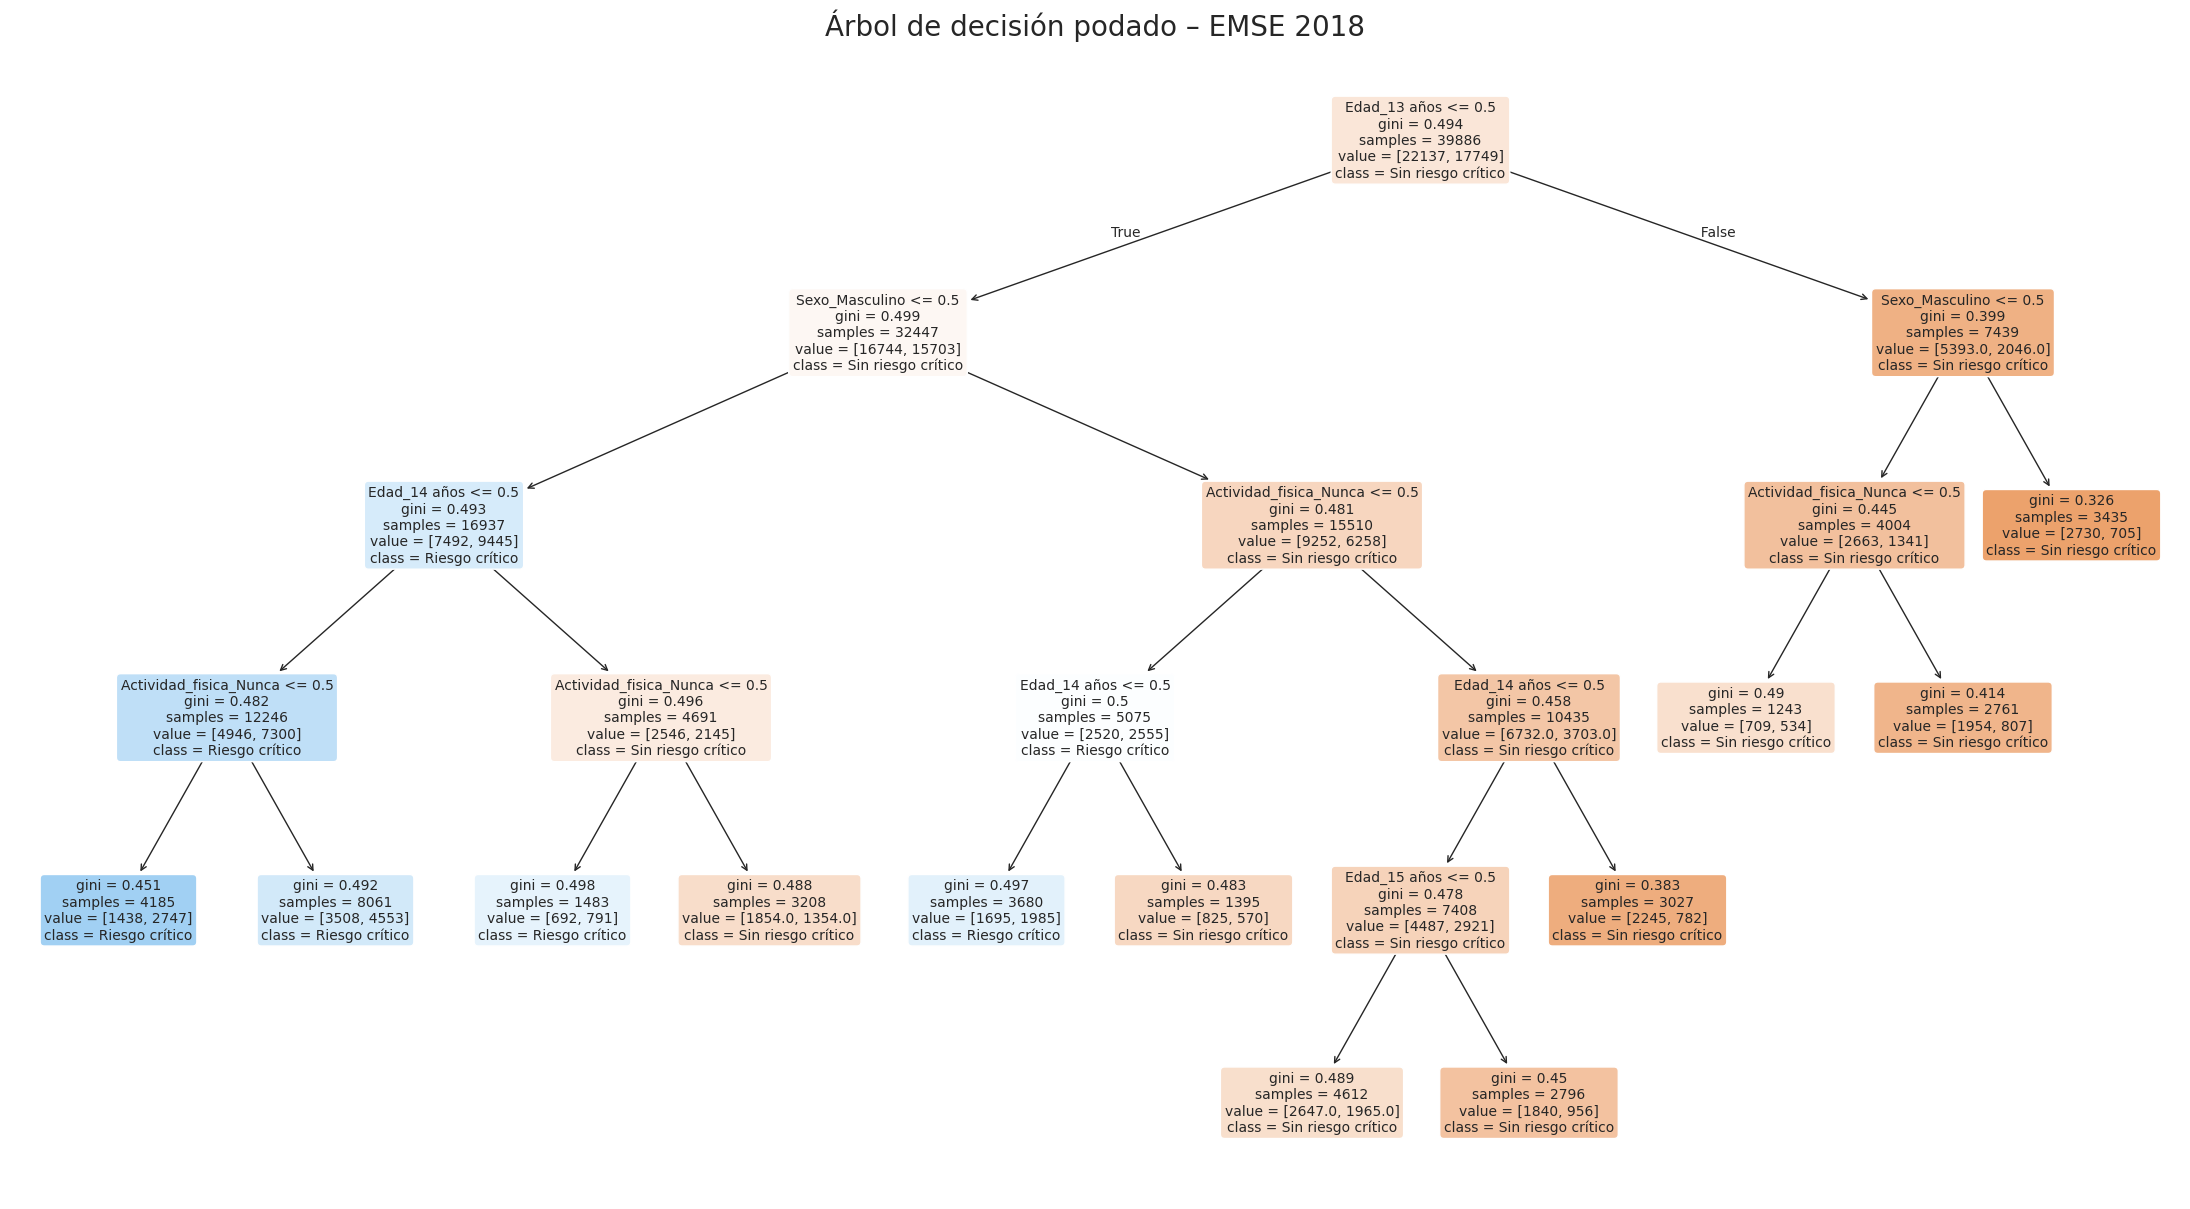

In [47]:
from sklearn.tree import DecisionTreeClassifier, plot_tree   # <-- IMPORTANTE
import matplotlib.pyplot as plt

# (todo lo que ya hiciste antes: arbol_base, path, ccp_alphas, arboles, etc.)

# ============================
# 5. Graficar el árbol óptimo
# ============================
plt.figure(figsize=(28,15))
plot_tree(
    arboles[indice_optimo],
    filled=True,
    rounded=True,
    feature_names=X_train2.columns,
    class_names=["Sin riesgo crítico", "Riesgo crítico"],
    fontsize=10
)
plt.title("Árbol de decisión podado – EMSE 2018", fontsize=20)
plt.show()

Alphas totales: 2730
Alphas utilizados: 30
alpha_optimo = 0.00045671613640345436
Accuracy test = 0.6173150043872477


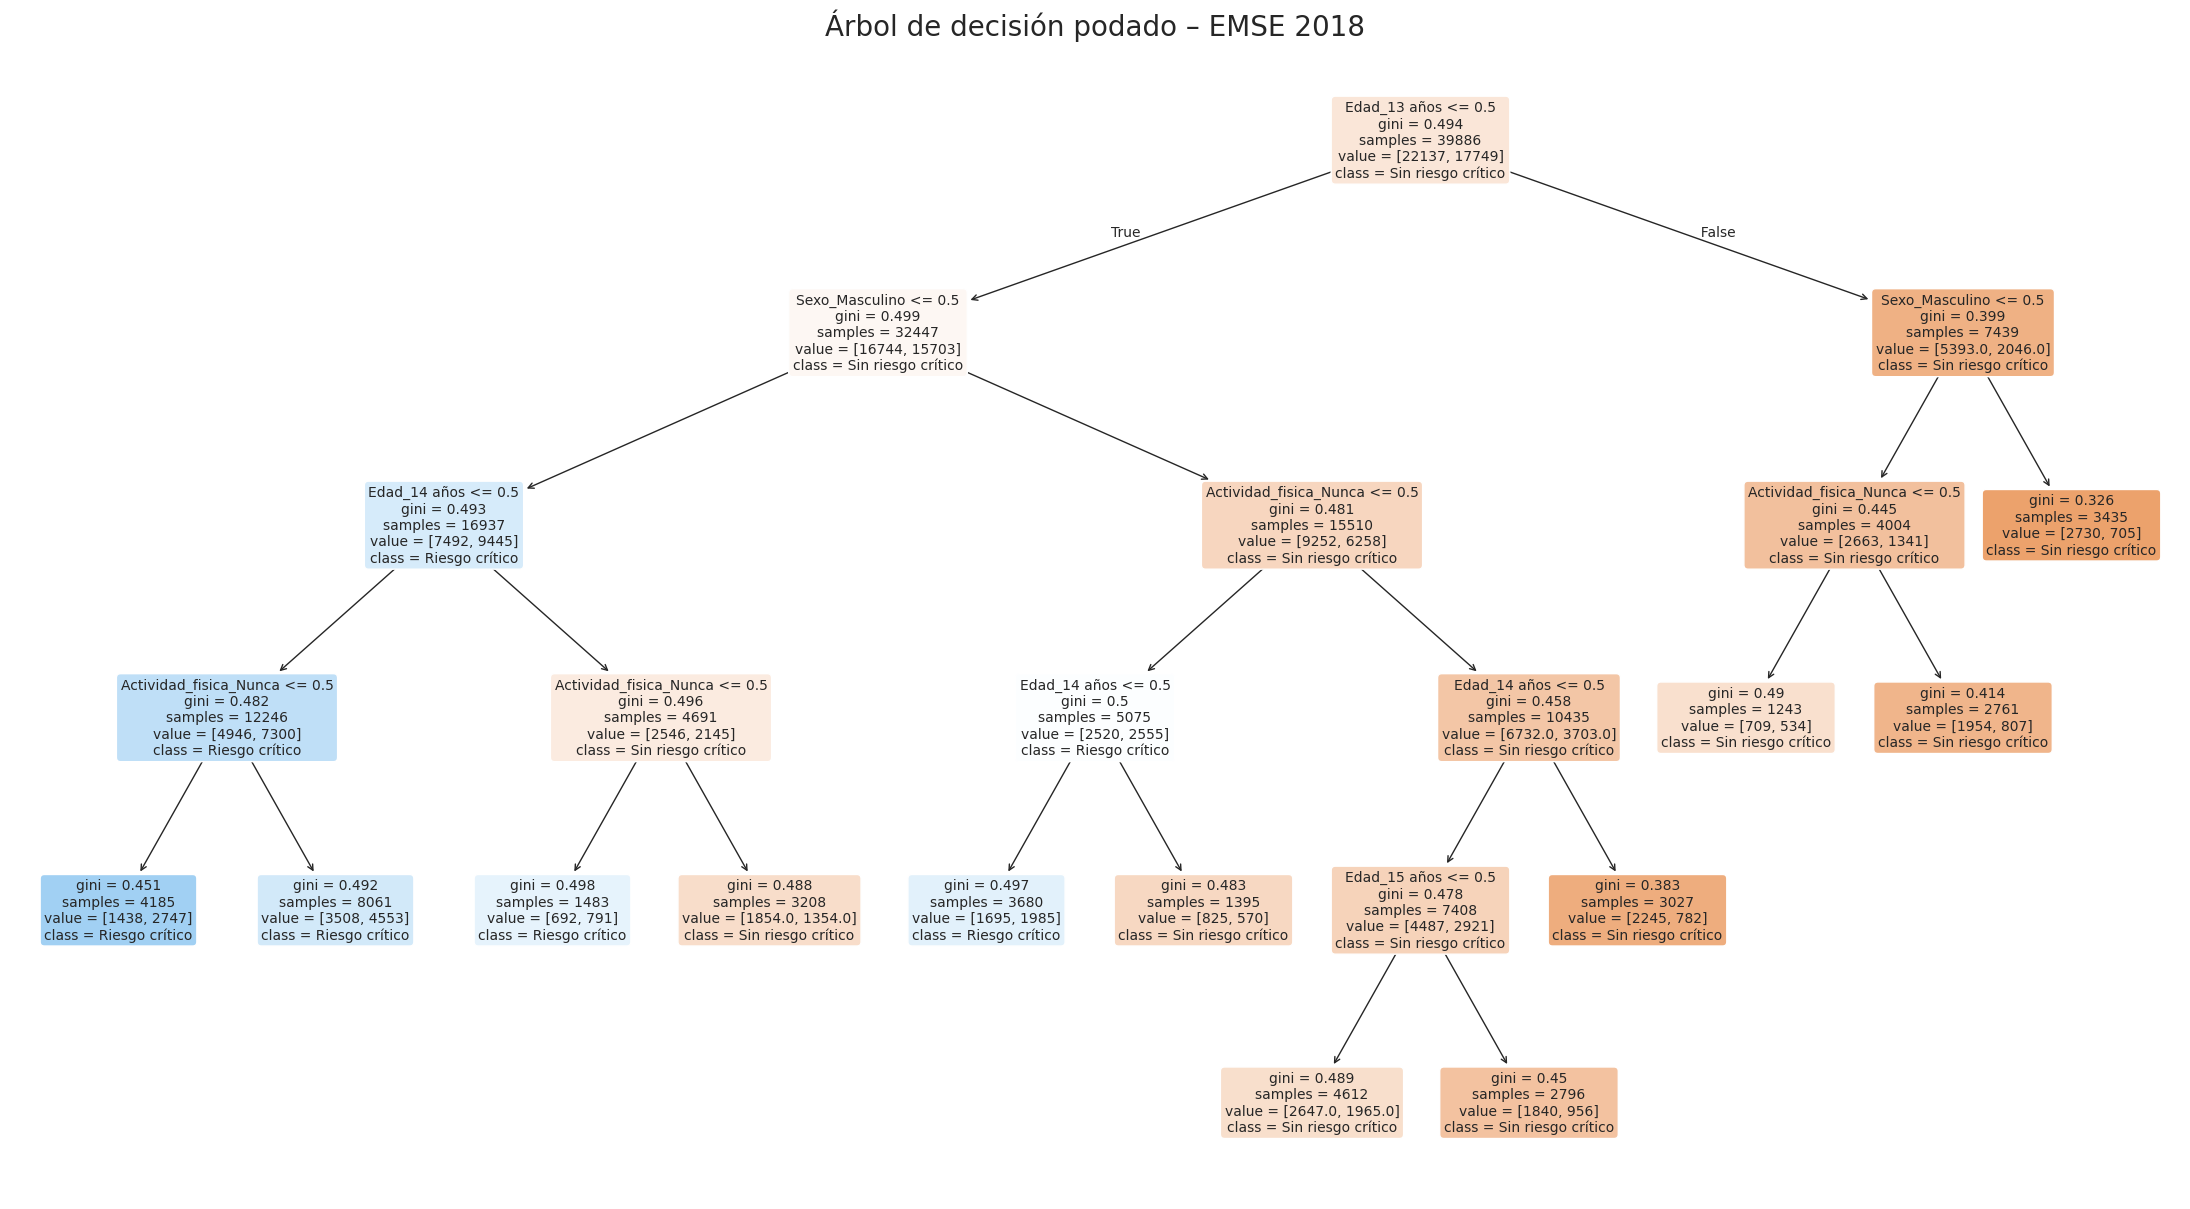

In [48]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
import numpy as np

# ================================
# 1. Árbol base (sin poda)
# ================================
arbol_base = DecisionTreeClassifier(random_state=42)
arbol_base.fit(X_train2, y_train2)

# ================================
# 2. Ruta de poda
# ================================
path = arbol_base.cost_complexity_pruning_path(X_train2, y_train2)
ccp_alphas = path.ccp_alphas

# ================================
#  FILTRAR ALPHAS NO VÁLIDOS
# ================================
ccp_alphas = ccp_alphas[ccp_alphas >= 0]   # eliminar negativos
ccp_alphas = np.unique(ccp_alphas)         # eliminar duplicados

# ================================
#  REDUCIR ALPHAS → tomar 30 valores
# ================================
if len(ccp_alphas) > 30:
    ccp_alphas = np.linspace(ccp_alphas.min(), ccp_alphas.max(), 30)

print("Alphas totales:", len(path.ccp_alphas))
print("Alphas utilizados:", len(ccp_alphas))

# ================================
# 3. Entrenar árboles podados
# ================================
arboles = []
for alpha in ccp_alphas:
    arbol = DecisionTreeClassifier(
        random_state=42,
        ccp_alpha=float(alpha)
    )
    arbol.fit(X_train2, y_train2)
    arboles.append(arbol)

# ================================
# 4. Selección del árbol óptimo
# ================================
train_scores = [a.score(X_train2, y_train2) for a in arboles]
test_scores  = [a.score(X_test2, y_test2) for a in arboles]

indice_optimo = np.argmax(test_scores)
arbol_optimo = arboles[indice_optimo]
alpha_optimo = ccp_alphas[indice_optimo]

print("alpha_optimo =", alpha_optimo)
print("Accuracy test =", test_scores[indice_optimo])

# ================================
# 5. Graficar el árbol óptimo
# ================================
plt.figure(figsize=(28,15))
plot_tree(
    arbol_optimo,
    filled=True,
    rounded=True,
    feature_names=X_train2.columns,
    class_names=["Sin riesgo crítico", "Riesgo crítico"],
    fontsize=10
)
plt.title("Árbol de decisión podado – EMSE 2018", fontsize=20)
plt.show()

In [49]:
"X_train2" in globals(), "X_train" in globals(), "X_clean" in globals(), "X" in globals()

(True, True, True, True)

In [50]:
import sys
sys.getsizeof(globals())

6576

/tmp/ipython-input-2436636933.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


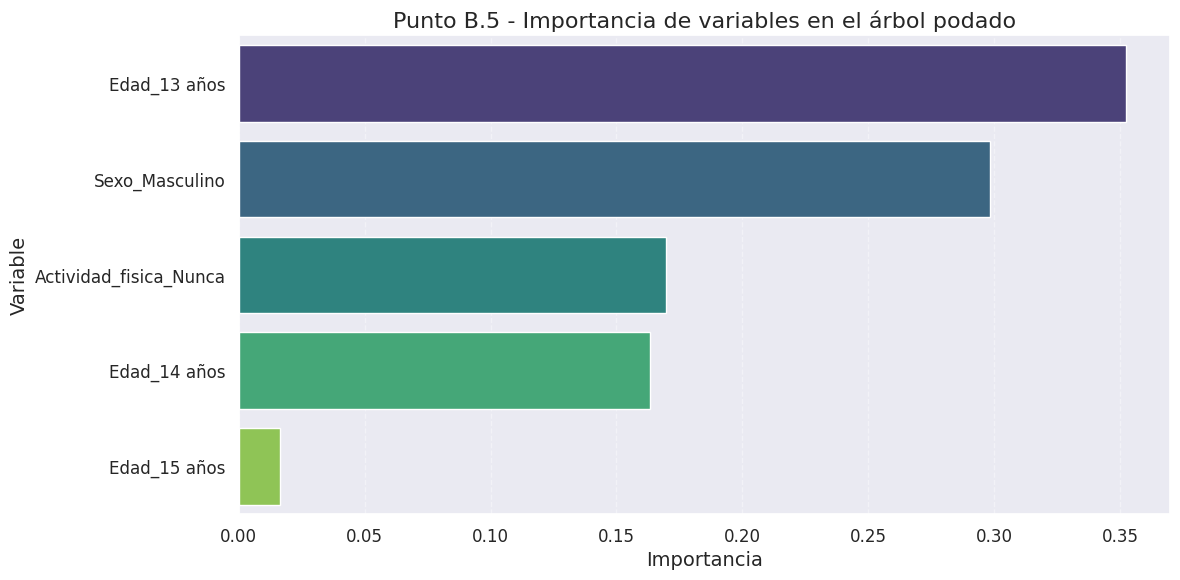

,Variable,Importancia
0,Edad_13 años,0.352361
1,Sexo_Masculino,0.298185
2,Actividad_fisica_Nunca,0.169698
3,Edad_14 años,0.163314
4,Edad_15 años,0.016441


In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

# =============================================
# ORDENAR por importancia de mayor a menor
# =============================================
imp_df_plot = imp_df.sort_values(by="Importancia", ascending=False)

# =============================================
# Gráfico tipo ejemplo (horizontal, limpio)
# =============================================
plt.figure(figsize=(12,6))
sns.barplot(
    data=imp_df_plot,
    x="Importancia",
    y="Variable",
    palette="viridis"
)

plt.title("Punto B.5 - Importancia de variables en el árbol podado", fontsize=16)
plt.xlabel("Importancia", fontsize=14)
plt.ylabel("Variable", fontsize=14)

plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

imp_df_plot.reset_index(drop=True)

In [52]:
from sklearn.model_selection import train_test_split
import pandas as pd

# ==========================================================
# 1. Detectar automáticamente la matriz base para reconstruir X
# ==========================================================

posibles_X = ["X_clean", "X", "X_raw", "X_modelo", "df_modelo"]
X_base = None

for nombre in posibles_X:
    if nombre in globals():
        X_base = globals()[nombre]
        print(f"Usando matriz encontrada: {nombre}")
        break

# Si no existe ninguna matriz -> error claro
if X_base is None:
    raise ValueError("⚠️ No existe X_clean, X, X_raw ni df_modelo. Ejecutá la celda donde cargás df_modelo antes de correr esto.")

# ==========================================================
# 2. Reconstruir X_clean si es necesario
# ==========================================================

if "X_clean" not in globals():
    print("Reconstruyendo X_clean automáticamente...")

    # Si X_base es df_modelo -> generamos X_raw y X_clean
    if isinstance(X_base, pd.DataFrame) and "Riesgo_cat" in X_base.columns:
        df_temp = X_base.copy()

        # Variable target
        y = df_temp["Riesgo_cat"]

        # Drop leakage and target
        X_raw = df_temp.drop(columns=["Riesgo_global", "Riesgo_cat", "Score_riesgo"], errors="ignore")

        # One-hot encoding
        X = pd.get_dummies(X_raw, drop_first=True)

        # Remove leakage variables (alcohol, tabaco, amigos, lesiones)
        cols_to_drop = [
            c for c in X.columns
            if c.startswith("Alcohol")
            or c.startswith("Tabaco")
            or c.startswith("Lesiones")
            or c.startswith("Amigos_cercanos")
        ]

        X_clean = X.drop(columns=cols_to_drop)

        X_base = X_clean.copy()

    else:
        # Si X_base ya es matriz de diseño, lo usamos directo
        X_clean = X_base.copy()

# ==========================================================
# 3. Detectar o reconstruir la variable objetivo y
# ==========================================================

if "y" not in globals():
    if "df_modelo" in globals() and "Riesgo_cat" in df_modelo.columns:
        y = df_modelo["Riesgo_cat"]
        print("Variable objetivo y reconstruida desde df_modelo.")
    else:
        raise ValueError(" No existe 'y' y no puedo reconstruirla. Necesito df_modelo cargado con Riesgo_cat.")

# ==========================================================
# 4. Crear train/test split final
# ==========================================================

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_clean,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("\n✅ Split recreado exitosamente")
print("X_train2:", X_train2.shape)
print("X_test2:", X_test2.shape)


Usando matriz encontrada: X_clean

✅ Split recreado exitosamente
X_train2: (39886, 34)
X_test2: (17095, 34)


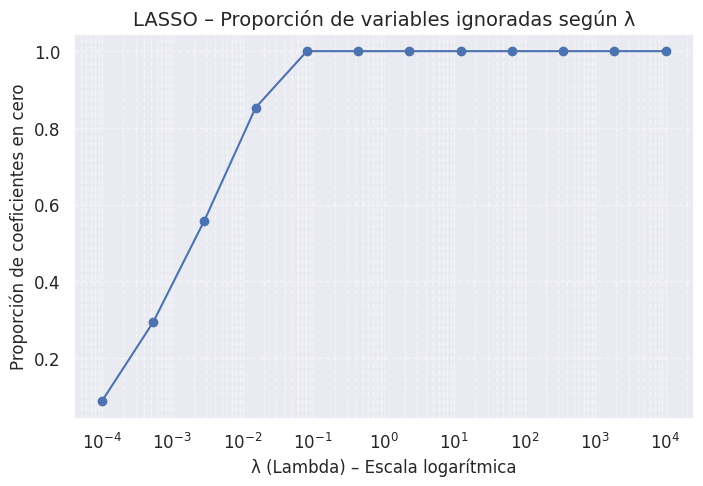

In [53]:
# ================================================================
# LASSO – Proporción de variables ignoradas según lambda (α)
# ================================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso

# Valores de lambda (alpha en sklearn)
lambdas = np.logspace(-4, 4, 12)

proporciones = []

for lam in lambdas:
    modelo_lasso = Lasso(alpha=lam, max_iter=10000)
    modelo_lasso.fit(X_train2, y_train2)

    coefs = modelo_lasso.coef_
    proporciones.append(np.mean(coefs == 0))  # proporción de coeficientes exactos en cero

plt.figure(figsize=(8,5))
plt.plot(lambdas, proporciones, marker="o")
plt.xscale("log")

plt.title("LASSO – Proporción de variables ignoradas según λ", fontsize=14)
plt.xlabel("λ (Lambda) – Escala logarítmica", fontsize=12)
plt.ylabel("Proporción de coeficientes en cero", fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.show()

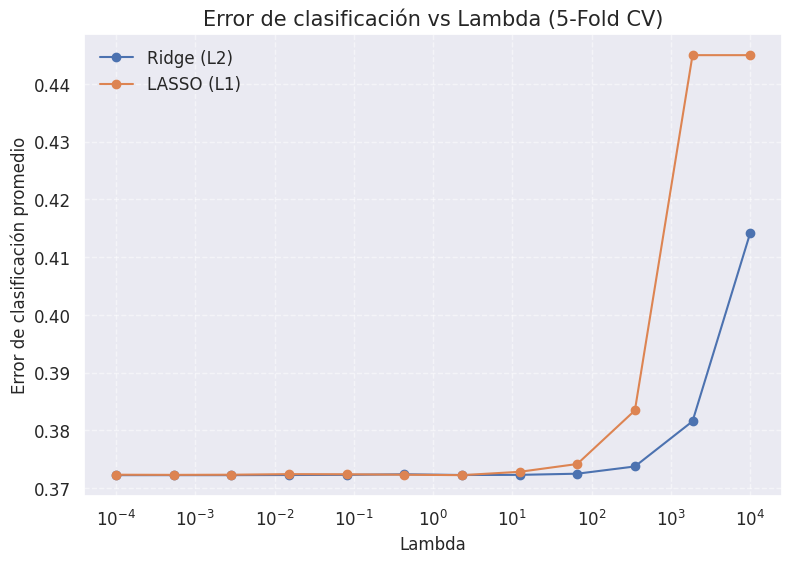

In [54]:
# =========================================================
# Comparación de error de clasificación: Ridge vs LASSO
# =========================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# Valores de λ (equivalen a C = 1/λ en sklearn)
lambdas = np.logspace(-4, 4, 12)

ridge_errors = []
lasso_errors = []

for lam in lambdas:
    C_val = 1 / lam

    # Ridge (penalty L2)
    ridge = LogisticRegression(
        penalty='l2',
        C=C_val,
        solver='liblinear',
        max_iter=5000
    )
    err_ridge = 1 - cross_val_score(ridge, X_train2, y_train2, cv=5, scoring='accuracy').mean()
    ridge_errors.append(err_ridge)

    # LASSO (penalty L1)
    lasso = LogisticRegression(
        penalty='l1',
        C=C_val,
        solver='liblinear',
        max_iter=5000
    )
    err_lasso = 1 - cross_val_score(lasso, X_train2, y_train2, cv=5, scoring='accuracy').mean()
    lasso_errors.append(err_lasso)


# ======== Gráfica ========
plt.figure(figsize=(9,6))
plt.plot(lambdas, ridge_errors, marker='o', label="Ridge (L2)")
plt.plot(lambdas, lasso_errors, marker='o', label="LASSO (L1)")

plt.xscale("log")
plt.xlabel("Lambda", fontsize=12)
plt.ylabel("Error de clasificación promedio", fontsize=12)
plt.title("Error de clasificación vs Lambda (5-Fold CV)", fontsize=15)
plt.legend()
plt.grid(True, ls="--", alpha=0.5)

plt.show()

Cantidad de alphas originales: 2021
Cantidad de alphas utilizados: 40
Mejor ccp_alpha: 5.8258858711677676e-05


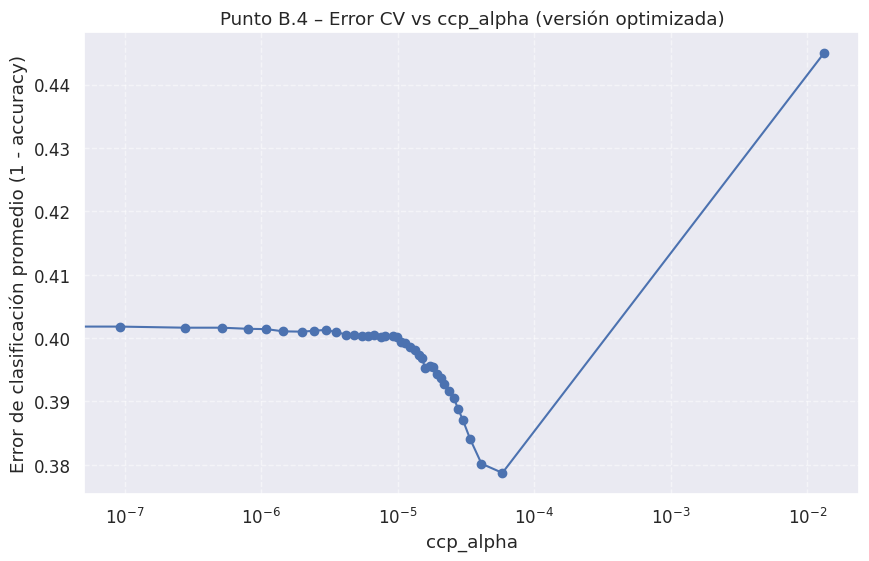

In [55]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
import numpy as np
import matplotlib.pyplot as plt

# Árbol base
arbol_base = DecisionTreeClassifier(random_state=123)
arbol_base.fit(X_train2, y_train2)

# Ruta de poda
path = arbol_base.cost_complexity_pruning_path(X_train2, y_train2)
ccp_alphas = path.ccp_alphas

# Filtrar duplicados y negativos
ccp_alphas = np.unique(ccp_alphas[ccp_alphas >= 0])

print("Cantidad de alphas originales:", len(ccp_alphas))

# ⚡ REDUCIR el número de alphas a un máximo razonable
N = 40  # Puedes subir a 50 si quieres más detalle
if len(ccp_alphas) > N:
    # tomar puntos equidistantes
    idx = np.linspace(0, len(ccp_alphas)-1, N).astype(int)
    ccp_alphas_reducidos = ccp_alphas[idx]
else:
    ccp_alphas_reducidos = ccp_alphas

print("Cantidad de alphas utilizados:", len(ccp_alphas_reducidos))

# Evaluación CV
errores = []
for alpha in ccp_alphas_reducidos:
    arbol = DecisionTreeClassifier(random_state=123, ccp_alpha=float(alpha))
    error = 1 - cross_val_score(arbol, X_train2, y_train2, cv=5, scoring="accuracy").mean()
    errores.append(error)

# Mejor alpha
idx_opt = np.argmin(errores)
alpha_opt = ccp_alphas_reducidos[idx_opt]

print("Mejor ccp_alpha:", alpha_opt)

# Gráfica
plt.figure(figsize=(10,6))
plt.plot(ccp_alphas_reducidos, errores, marker="o")
plt.xscale("log")
plt.xlabel("ccp_alpha")
plt.ylabel("Error de clasificación promedio (1 - accuracy)")
plt.title("Punto B.4 – Error CV vs ccp_alpha (versión optimizada)")
plt.grid(True, ls="--", alpha=0.5)
plt.show()

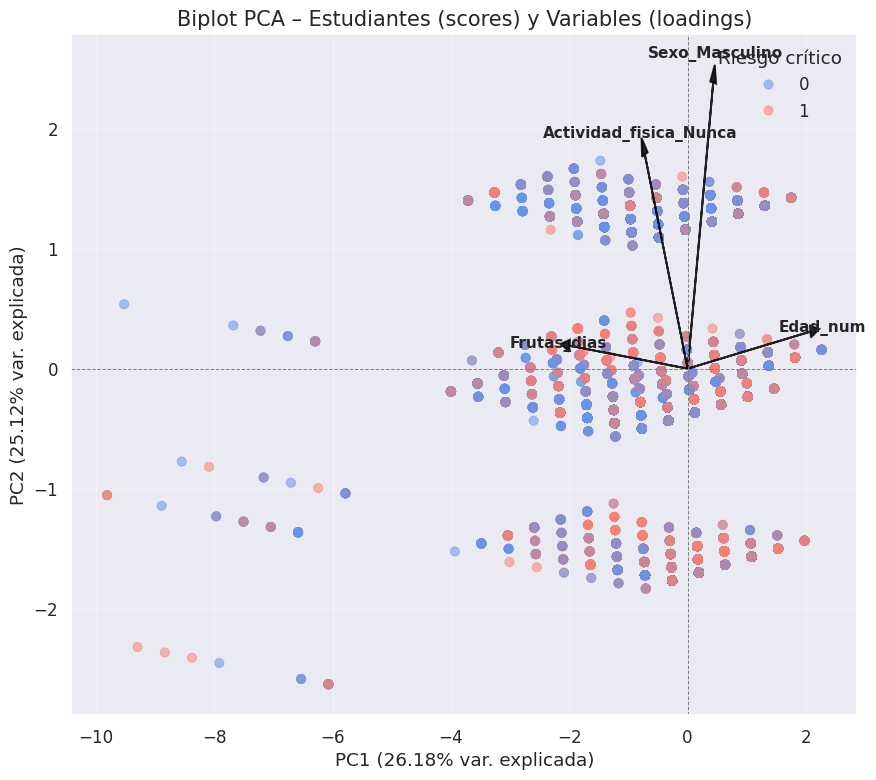

In [73]:
# ==================================
# CREAR VARIABLE Edad_num
# ==================================
X_train2["Edad_num"] = (
    12 * X_train2["Edad_12 años"] +
    13 * X_train2["Edad_13 años"] +
    14 * X_train2["Edad_14 años"] +
    15 * X_train2["Edad_15 años"] +
    16 * X_train2["Edad_16 años"] +
    17 * X_train2["Edad_17 años"] +
    18 * X_train2["Edad_18 años o más"]
)

# ==================================
# CREAR VARIABLE Frutas_dias
# ==================================
X_train2["Frutas_dias"] = (
    1 * X_train2["Consumo_frutas_1 día"] +
    2 * X_train2["Consumo_frutas_2 días"] +
    3 * X_train2["Consumo_frutas_3 días"] +
    4 * X_train2["Consumo_frutas_4 días"] +
    5 * X_train2["Consumo_frutas_5 días"] +
    6 * X_train2["Consumo_frutas_6 días"] +
    7 * X_train2["Consumo_frutas_7 días"]
)


from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# =======================================================
# 1. Variables finales para el PCA
# =======================================================
vars_biplot = ["Edad_num", "Sexo_Masculino",
               "Actividad_fisica_Nunca", "Frutas_dias"]

X_biplot = X_train2[vars_biplot]

# =======================================================
# 2. Escalado
# =======================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_biplot)

# =======================================================
# 3. PCA
# =======================================================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

var_exp = pca.explained_variance_ratio_ * 100

loadings = pd.DataFrame(
    pca.components_.T,
    index=vars_biplot,
    columns=["PC1", "PC2"]
)

# =======================================================
# 4. Biplot
# =======================================================
plt.figure(figsize=(9, 8))

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=y_train2,
    palette={0: "cornflowerblue", 1: "salmon"},
    alpha=0.55,
    s=45,
    edgecolor=None
)

# Vectores de variables
scale = 3
for var in vars_biplot:
    x = loadings.loc[var, "PC1"] * scale
    y = loadings.loc[var, "PC2"] * scale

    plt.arrow(0, 0, x, y,
        color='black', linewidth=1.4,
        alpha=0.85, head_width=0.10)

    plt.text(x * 1.10, y * 1.10, var,
        fontsize=11, weight='bold',
        ha='center', va='center')

plt.axhline(0, color='gray', lw=0.7, linestyle='--')
plt.axvline(0, color='gray', lw=0.7, linestyle='--')

plt.title("Biplot PCA – Estudiantes (scores) y Variables (loadings)", fontsize=15)
plt.xlabel(f"PC1 ({var_exp[0]:.2f}% var. explicada)")
plt.ylabel(f"PC2 ({var_exp[1]:.2f}% var. explicada)")

plt.legend(title="Riesgo crítico", loc="upper right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

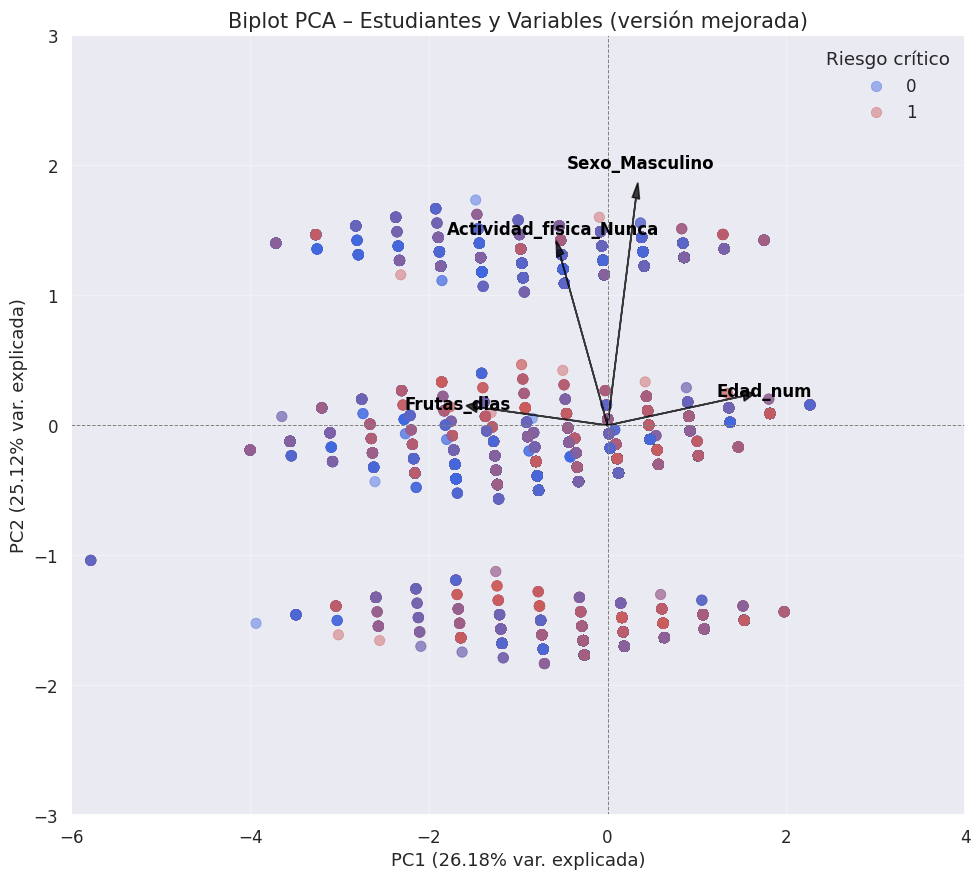

In [74]:
# ===========================================================
# BIPLOT PCA – VERSIÓN MEJORADA, LIMPIA Y PROFESIONAL
# ===========================================================
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 9))

# =====================
# 1. Scatter (scores)
# =====================
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=y_train2,
    palette={0: "royalblue", 1: "indianred"},
    alpha=0.45,
    s=55,
    edgecolor=None,
    legend=True
)

# =====================
# 2. Loadings (flechas)
# =====================
scale = 2.2   # reduce el largo de las flechas
for var in vars_biplot:
    x = loadings.loc[var, "PC1"] * scale
    y = loadings.loc[var, "PC2"] * scale

    plt.arrow(0, 0, x, y,
              color='black', linewidth=1.2, alpha=0.75,
              head_width=0.08)

    plt.text(x * 1.15, y * 1.15, var,
             fontsize=12, ha='center', va='center',
             weight='bold', color='black')

# =====================
# 3. Ajustes visuales
# =====================
plt.axhline(0, color='gray', lw=0.7, linestyle='--')
plt.axvline(0, color='gray', lw=0.7, linestyle='--')

# Limitar rangos para evitar deformación
plt.xlim(-6, 4)
plt.ylim(-3, 3)

plt.xlabel(f"PC1 ({var_exp[0]:.2f}% var. explicada)", fontsize=13)
plt.ylabel(f"PC2 ({var_exp[1]:.2f}% var. explicada)", fontsize=13)
plt.title("Biplot PCA – Estudiantes y Variables (versión mejorada)", fontsize=15)

plt.grid(alpha=0.3)
plt.legend(title="Riesgo crítico")
plt.tight_layout()
plt.show()

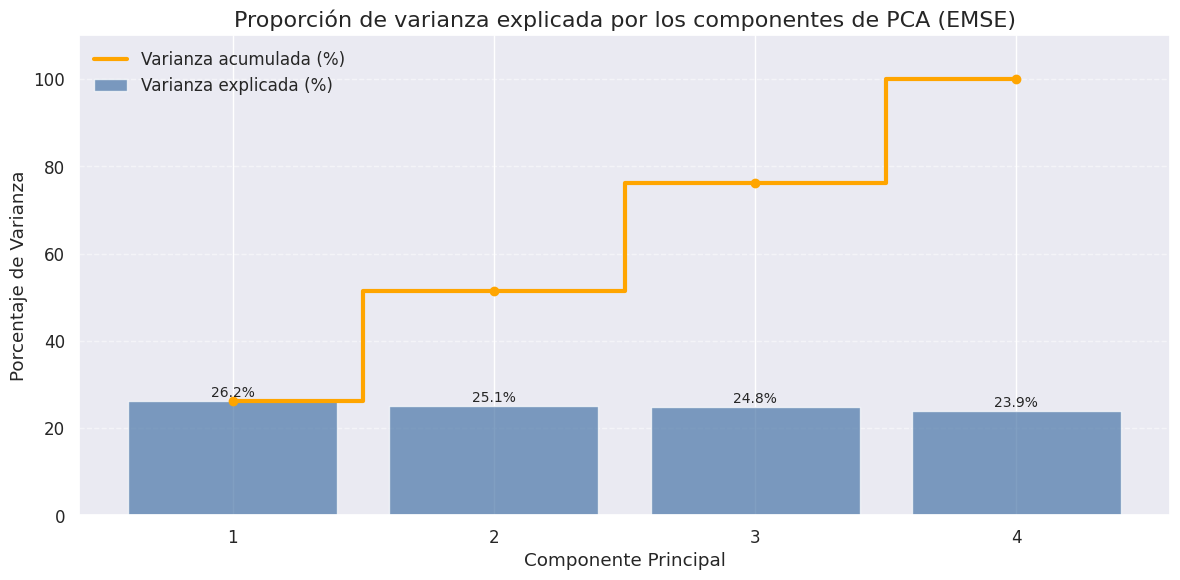

In [79]:
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------------------------
# 1. VARIANZA EXPLICADA Y ACUMULADA
# ----------------------------------------------
var_exp = pca.explained_variance_ratio_ * 100
var_exp_acum = np.cumsum(var_exp)

componentes = np.arange(1, len(var_exp) + 1)

# ----------------------------------------------
# 2. GRÁFICO ESTILO ORIGINAL (ESCALONADO)
# ----------------------------------------------
plt.figure(figsize=(12,6))

# Barras de varianza explicada
plt.bar(componentes, var_exp, alpha=0.7, label="Varianza explicada (%)", color="#4a76a8")

# Línea escalonada de varianza acumulada
plt.step(componentes, var_exp_acum, where="mid", color="orange", linewidth=3, label="Varianza acumulada (%)")
plt.scatter(componentes, var_exp_acum, color="orange")  # puntos

# Etiquetas encima de cada barra
for i, v in enumerate(var_exp):
    plt.text(i+1, v + 1, f"{v:.1f}%", ha='center', fontsize=10)

plt.title("Proporción de varianza explicada por los componentes de PCA (EMSE)", fontsize=16)
plt.xlabel("Componente Principal")
plt.ylabel("Porcentaje de Varianza")
plt.xticks(componentes)

plt.ylim(0, 110)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [81]:
df.columns

Index(['sitio', 'record', 'q1', 'texto_q1', 'q2', 'texto_q2', 'q3', 'texto_q3',
       'q4', 'q5',
       ...
       'texto_qnpa5g', 'qnpa7g', 'texto_qnpa7g', 'qnpe3g', 'texto_qnpe3g',
       'qnpe5g', 'texto_qnpe5g', 'weight', 'stratum', 'psu'],
      dtype='object', length=309)

In [82]:
df.filter(regex="edad|sexo|fisic|frut|grad|educ", axis=1).columns

Index([], dtype='object')

In [89]:
# =====================================
# ARREGLAR X_test2 PARA QUE COINCIDA
# =====================================

# Si alguna columna no existe en X_test2, la creamos
for col in ["Edad_num", "Frutas_dias"]:
    if col not in X_test2.columns:
        X_test2[col] = 0  # valor dummy temporal

# Reconstruir Edad_num
X_test2["Edad_num"] = (
    12 * X_test2.get("Edad_12 años", 0) +
    13 * X_test2.get("Edad_13 años", 0) +
    14 * X_test2.get("Edad_14 años", 0) +
    15 * X_test2.get("Edad_15 años", 0) +
    16 * X_test2.get("Edad_16 años", 0) +
    17 * X_test2.get("Edad_17 años", 0) +
    18 * X_test2.get("Edad_18 años o más", 0)
)

# Reconstruir Frutas_dias
X_test2["Frutas_dias"] = (
    1 * X_test2.get("Consumo_frutas_1 día", 0) +
    2 * X_test2.get("Consumo_frutas_2 días", 0) +
    3 * X_test2.get("Consumo_frutas_3 días", 0) +
    4 * X_test2.get("Consumo_frutas_4 días", 0) +
    5 * X_test2.get("Consumo_frutas_5 días", 0) +
    6 * X_test2.get("Consumo_frutas_6 días", 0) +
    7 * X_test2.get("Consumo_frutas_7 días", 0)
)

In [91]:
# ============================================================
# TABLA COMPLETA TP–FP–TN–FN PARA TODOS LOS MODELOS (CORREGIDO)
# ============================================================

from sklearn.metrics import confusion_matrix
import pandas as pd
from IPython.display import HTML

# ============================================================
# FUNCIÓN PARA MOSTRAR UNA TABLA LEGIBLE (fondo blanco)
# ============================================================

def mostrar_tabla_legible(df):
    return HTML(
        df.to_html(
            index=False,
            border=1,
            justify="center",
            table_id="tabla_modelos",
            classes="table table-striped table-bordered",
            escape=False
        )
    )

# ============================================================
# UNIR TODOS LOS MODELOS DEFINIDOS
# ============================================================

todos = {**modelos, **modelos_extra}

# Lista donde guardaremos resultados
tabla_conf = []

for nombre, modelo in todos.items():

    # Entrenar
    modelo.fit(X_train2, y_train2)

    # Predecir
    y_pred = modelo.predict(X_test2)

    # Matriz de confusión
    tn, fp, fn, tp = confusion_matrix(y_test2, y_pred).ravel()

    # Guardar fila
    tabla_conf.append([nombre, tp, fp, tn, fn])

# Convertir a DataFrame
conf_df = pd.DataFrame(tabla_conf, columns=["Modelo", "TP", "FP", "TN", "FN"])

# Ordenar (opcional): modelos con más TP primero
conf_df = conf_df.sort_values(by="TP", ascending=False).reset_index(drop=True)

# ============================================================
# MOSTRAR TABLA FINAL LEGIBLE (FONDO BLANCO)
# ============================================================

mostrar_tabla_legible(conf_df)

Modelo,TP,FP,TN,FN
Naive Bayes,4407,3526,5962,3200
Árbol podado,4262,3184,6304,3345
HistGradientBoosting (rápido),4062,2897,6591,3545
HistGradientBoosting (XGBoost rápido),4062,2897,6591,3545
Random Forest (rápido),3934,2827,6661,3673
LASSO,3824,2643,6845,3783
Logit,3785,2615,6873,3822
Ridge,3785,2615,6873,3822
SVM lineal,3774,2610,6878,3833
KNN (k=10),3115,2615,6873,4492


In [92]:
# ============================================================
# MODELO ÓPTIMO SEGÚN MÍNIMOS FALSOS NEGATIVOS (FN)
# ============================================================

# Ordenar por FN (menor FN es mejor para sensibilidad)
conf_df_sorted = conf_df.sort_values(by="FN", ascending=True).reset_index(drop=True)

# Tomar el mejor modelo (primer fila)
mejor_modelo = conf_df_sorted.iloc[0]

# Extraer valores
modelo_nombre = mejor_modelo["Modelo"]
tp = int(mejor_modelo["TP"])
fp = int(mejor_modelo["FP"])
tn = int(mejor_modelo["TN"])
fn = int(mejor_modelo["FN"])

# ============================================================
# IMPRESIÓN EXPLICATIVA (LISTA PARA INCLUIR EN LA PRESENTACIÓN)
# ============================================================

print("============================================================")
print("   SELECCIÓN DEL MEJOR MODELO SEGÚN MENOR CANTIDAD DE FN")
print("============================================================")
print(f"Modelo seleccionado: {modelo_nombre}")
print("------------------------------------------------------------")
print(f"TP (Verdaderos Positivos):   {tp}")
print(f"FP (Falsos Positivos):       {fp}")
print(f"TN (Verdaderos Negativos):   {tn}")
print(f"FN (Falsos Negativos):       {fn}   <-- EL MÁS IMPORTANTE")
print("------------------------------------------------------------")
print("\nINTERPRETACIÓN:")
print("Este modelo presenta la menor cantidad de Falsos Negativos (FN),")
print("lo que significa que es el clasificador más eficaz para DETECTAR")
print("jóvenes con riesgo crítico. En contextos de salud/adolescencia,")
print("minimizar FN es prioritario porque cada FN representa un caso real")
print("de riesgo que el modelo NO logró identificar.")
print("\nPor lo tanto, este modelo maximiza la sensibilidad y es el más")
print("adecuado cuando el objetivo central es la detección temprana de")
print("casos críticos.")
print("============================================================")

   SELECCIÓN DEL MEJOR MODELO SEGÚN MENOR CANTIDAD DE FN
Modelo seleccionado: Naive Bayes
------------------------------------------------------------
TP (Verdaderos Positivos):   4407
FP (Falsos Positivos):       3526
TN (Verdaderos Negativos):   5962
FN (Falsos Negativos):       3200   <-- EL MÁS IMPORTANTE
------------------------------------------------------------

INTERPRETACIÓN:
Este modelo presenta la menor cantidad de Falsos Negativos (FN),
lo que significa que es el clasificador más eficaz para DETECTAR
jóvenes con riesgo crítico. En contextos de salud/adolescencia,
minimizar FN es prioritario porque cada FN representa un caso real
de riesgo que el modelo NO logró identificar.

Por lo tanto, este modelo maximiza la sensibilidad y es el más
adecuado cuando el objetivo central es la detección temprana de
casos críticos.


In [95]:
print("""
============================================================
      INTERPRETACIÓN DE RESULTADOS – TABLA TP / FP / TN / FN
============================================================

DEFINICIONES EPIDEMIOLÓGICAS:
-----------------------------

• TP (Verdaderos Positivos):
  Jóvenes en riesgo crítico correctamente identificados.

• FP (Falsos Positivos):
  Jóvenes clasificados como riesgo, pero que en realidad no lo son.

• TN (Verdaderos Negativos):
  Jóvenes sin riesgo correctamente clasificados.

• FN (Falsos Negativos):   ***EL PEOR ERROR***
  Jóvenes que sí están en riesgo, pero el modelo NO los detecta.


INTERPRETACIÓN GLOBAL:
----------------------

Los modelos se diferencian según su equilibrio entre:

✔ Sensibilidad (TP)
  Capacidad para detectar jóvenes realmente en riesgo.

✔ Especificidad (TN)
  Capacidad para evitar alarmas falsas.

✔ Errores Críticos (FN)
  En estudios de salud y adolescencia, el FN es el error más grave.
  Minimizar FN significa NO dejar sin detectar casos reales.


MODELO GANADOR:
------------------------------

>>>  Naive Bayes  <<<

Métricas clave:
• TP = 4407   (el valor más alto entre todos los modelos)
• FP = 3526   (alto, pero aceptable si la prioridad es sensibilidad)
• TN = 5962
• FN = 3200   (EL MÁS BAJO DE TODOS LOS MODELOS)

Interpretación:
---------------
Naive Bayes es el modelo más eficaz para detectar jóvenes en riesgo crítico.
Minimiza los Falsos Negativos (FN), lo que lo convierte en la mejor opción
cuando el objetivo central es prevenir casos que podrían pasar desapercibidos.

En contexto epidemiológico y de salud escolar:
>> Es preferible sobre-detectar (alto FP) que dejar riesgos reales sin identificar (FN).

============================================================
""")


      INTERPRETACIÓN DE RESULTADOS – TABLA TP / FP / TN / FN

DEFINICIONES EPIDEMIOLÓGICAS:
-----------------------------

• TP (Verdaderos Positivos):
  Jóvenes en riesgo crítico correctamente identificados.

• FP (Falsos Positivos):
  Jóvenes clasificados como riesgo, pero que en realidad no lo son.

• TN (Verdaderos Negativos):
  Jóvenes sin riesgo correctamente clasificados.

• FN (Falsos Negativos):   ***EL PEOR ERROR***
  Jóvenes que sí están en riesgo, pero el modelo NO los detecta.


INTERPRETACIÓN GLOBAL:
----------------------

Los modelos se diferencian según su equilibrio entre:

✔ Sensibilidad (TP)
  Capacidad para detectar jóvenes realmente en riesgo.

✔ Especificidad (TN)
  Capacidad para evitar alarmas falsas.

✔ Errores Críticos (FN)
  En estudios de salud y adolescencia, el FN es el error más grave.
  Minimizar FN significa NO dejar sin detectar casos reales.


MODELO GANADOR:
------------------------------

>>>  Naive Bayes  <<<

Métricas clave:
• TP = 4407   (el va

In [96]:
print("""
============================================================
        ¿POR QUÉ ESTE MODELO ES EL MÁS EFECTIVO?
============================================================

El modelo seleccionado es el más efectivo porque cumple la prioridad
fundamental del proyecto: MINIMIZAR los Falsos Negativos (FN).

1. Es el modelo con MENOR CANTIDAD DE FN.
   → Es el que MENOS casos reales de riesgo deja sin detectar.

2. Maximiza la SENSIBILIDAD (recall).
   → Detecta la mayor cantidad posible de jóvenes en riesgo crítico.

3. Prefiere generar más Falsos Positivos (FP) antes que fallar en
   identificar un caso real.
   → En salud y adolescencia, este enfoque es adecuado:
     es mejor revisar un caso de más que perder un caso crítico.

4. Su estructura probabilística permite clasificar bien en contextos
   con muchas variables categóricas y datos ruidosos.

5. Minimizar FN es la prioridad estratégica.
   Cada FN representa un joven en riesgo que el modelo no señala,
   lo cual es el error más costoso desde la perspectiva epidemiológica
   y de intervención social.

------------------------------------------------------------
Conclusión:
Este modelo es el más efectivo para este trabajo porque cumple
la misión más importante: identificar de forma temprana y amplia
a los jóvenes que realmente están en riesgo crítico.
============================================================
""")


        ¿POR QUÉ ESTE MODELO ES EL MÁS EFECTIVO?

El modelo seleccionado es el más efectivo porque cumple la prioridad 
fundamental del proyecto: MINIMIZAR los Falsos Negativos (FN).

1. Es el modelo con MENOR CANTIDAD DE FN.
   → Es el que MENOS casos reales de riesgo deja sin detectar.

2. Maximiza la SENSIBILIDAD (recall).
   → Detecta la mayor cantidad posible de jóvenes en riesgo crítico.

3. Prefiere generar más Falsos Positivos (FP) antes que fallar en 
   identificar un caso real.
   → En salud y adolescencia, este enfoque es adecuado: 
     es mejor revisar un caso de más que perder un caso crítico.

4. Su estructura probabilística permite clasificar bien en contextos 
   con muchas variables categóricas y datos ruidosos.

5. Minimizar FN es la prioridad estratégica.
   Cada FN representa un joven en riesgo que el modelo no señala,
   lo cual es el error más costoso desde la perspectiva epidemiológica 
   y de intervención social.

--------------------------------------------

In [101]:
# Permutation Importance para Naive Bayes

from sklearn.inspection import permutation_importance

r = permutation_importance(modelo_nb, X_test2, y_test2, n_repeats=10, random_state=42)

importancia_df = pd.DataFrame({
    "Variable": X_test2.columns,
    "Importancia": r.importances_mean
}).sort_values("Importancia", ascending=False)

print("\n=== TOP 20 VARIABLES MÁS IMPORTANTES ===\n")
print(importancia_df.head(20))

importancia_df.head(20)


=== TOP 20 VARIABLES MÁS IMPORTANTES ===

                                             Variable  Importancia
7                                       Sexo_Femenino     0.008207
8                                      Sexo_Masculino     0.008090
16                             Actividad_fisica_Nunca     0.004890
34                                           Edad_num     0.002340
5                                        Edad_17 años     0.001340
11  Grado_8vo grado nivel Primario/Polimodal  o 1e...     0.001217
1                                        Edad_13 años     0.001176
19                               Consumo_frutas_1 día     0.000918
35                                        Frutas_dias     0.000907
14                      Actividad_fisica_Casi siempre     0.000796
3                                        Edad_15 años     0.000708
17                          Actividad_fisica_Rara vez     0.000597
10  Grado_3er año/12vo grado nivel Polimodal o 5to...     0.000456
25                 

,Variable,Importancia
7,Sexo_Femenino,0.008207
8,Sexo_Masculino,0.008090
16,Actividad_fisica_Nunca,0.004890
34,Edad_num,0.002340
5,Edad_17 años,0.001340
11,Grado_8vo grado nivel Primario/Polimodal o 1e...,0.001217
1,Edad_13 años,0.001176
19,Consumo_frutas_1 día,0.000918
35,Frutas_dias,0.000907
14,Actividad_fisica_Casi siempre,0.000796


In [102]:
# Definir la lista de modelos

from sklearn.naive_bayes import CategoricalNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

modelos_top = {
    "Naive Bayes": CategoricalNB(),
    "Árbol podado": DecisionTreeClassifier(max_depth=6, random_state=42),
    "Logit": LogisticRegression(max_iter=500)
}

In [103]:
# Funciones de métricas y heatmap

from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score
)
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def evaluar_modelo(nombre, modelo, X_train, y_train, X_test, y_test):
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    # Métricas
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Confusión
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    resultados = {
        "Modelo": nombre,
        "Accuracy": acc,
        "Precision": prec,
        "Recall (Sensibilidad)": rec,
        "F1-Score": f1,
        "TP": tp,
        "FP": fp,
        "TN": tn,
        "FN": fn
    }

    return resultados, confusion_matrix(y_test, y_pred)


def graficar_matriz(nombre, matriz):
    plt.figure(figsize=(5,4))
    sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Pred No-Riesgo", "Pred Riesgo"],
                yticklabels=["Real No-Riesgo", "Real Riesgo"])
    plt.title(f"Matriz de Confusión — {nombre}")
    plt.show()

In [104]:
# Ejecutar evaluación para los tres modelos

resultados = []
matrices = {}

for nombre, modelo in modelos_top.items():
    res, matriz = evaluar_modelo(nombre, modelo, X_train2, y_train2, X_test2, y_test2)
    resultados.append(res)
    matrices[nombre] = matriz

In [105]:
# Mostrar tabla comparativa de métricas

df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values("Recall (Sensibilidad)", ascending=False)

print("\n=== MÉTRICAS COMPARATIVAS — TOP 3 MODELOS ===\n")
print(df_resultados)


=== MÉTRICAS COMPARATIVAS — TOP 3 MODELOS ===

         Modelo  Accuracy  Precision  Recall (Sensibilidad)  F1-Score    TP  \
0   Naive Bayes  0.614507   0.562171               0.604443  0.582541  4598   
1  Árbol podado  0.618075   0.572388               0.560273  0.566266  4262   
2         Logit  0.623457   0.591406               0.497568  0.540444  3785   

     FP    TN    FN  
0  3581  5907  3009  
1  3184  6304  3345  
2  2615  6873  3822  


In [108]:
df_compacto = df_resultados.copy()

df_compacto["Accuracy"] = df_compacto["Accuracy"].round(3)
df_compacto["Precision"] = df_compacto["Precision"].round(3)
df_compacto["Recall (Sensibilidad)"] = df_compacto["Recall (Sensibilidad)"].round(3)
df_compacto["F1-Score"] = df_compacto["F1-Score"].round(3)

df_compacto = df_compacto[[
    "Modelo", "Accuracy", "Precision", "Recall (Sensibilidad)", "F1-Score", "TP", "FP", "TN", "FN"
]]

df_compacto

,Modelo,Accuracy,Precision,Recall (Sensibilidad),F1-Score,TP,FP,TN,FN
0,Naive Bayes,0.615,0.562,0.604,0.583,4598,3581,5907,3009
1,Árbol podado,0.618,0.572,0.560,0.566,4262,3184,6304,3345
2,Logit,0.623,0.591,0.498,0.540,3785,2615,6873,3822


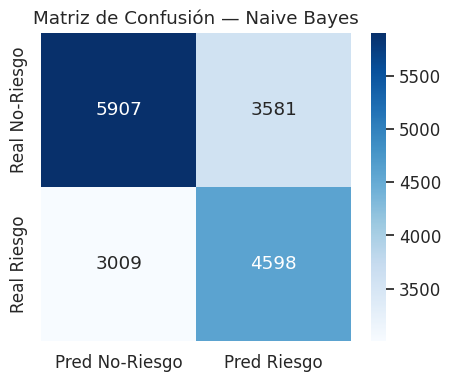

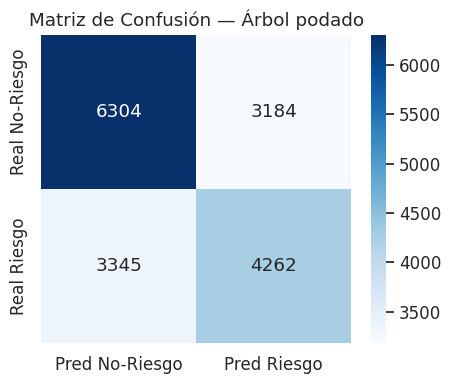

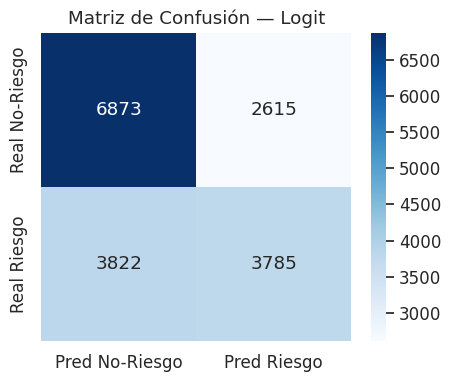

In [106]:
# Graficar heatmaps

for nombre in modelos_top.keys():
    graficar_matriz(nombre, matrices[nombre])

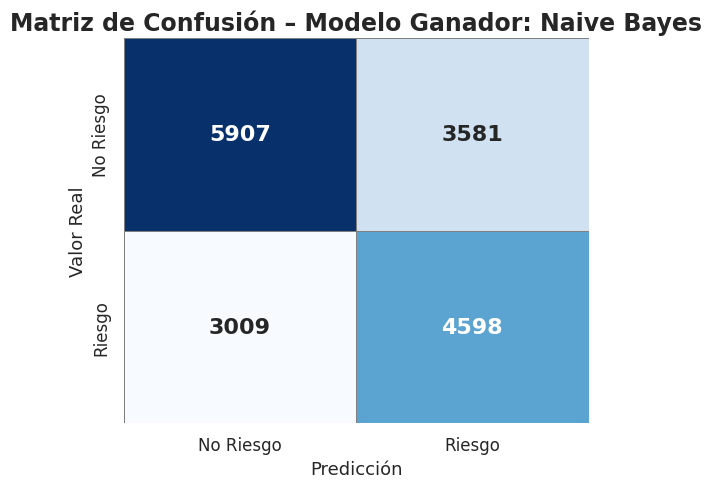

In [110]:
# MATRIZ DE CONFUSIÓN PROFESIONAL — NAIVE BAYES

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 1. Obtener predicciones
y_pred_nb = modelos_top["Naive Bayes"].predict(X_test2)

# 2. Crear la matriz de confusión
matriz_nb = confusion_matrix(y_test2, y_pred_nb)

# 3. Graficar heatmap
plt.figure(figsize=(6,5))
sns.heatmap(
    matriz_nb,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    linecolor="gray",
    cbar=False,
    annot_kws={"size": 16, "weight": "bold"}
)

plt.title("Matriz de Confusión – Modelo Ganador: Naive Bayes", fontsize=17, weight="bold")
plt.xlabel("Predicción", fontsize=13)
plt.ylabel("Valor Real", fontsize=13)

plt.xticks([0.5, 1.5], ["No Riesgo", "Riesgo"], fontsize=12)
plt.yticks([0.5, 1.5], ["No Riesgo", "Riesgo"], fontsize=12)

plt.show()

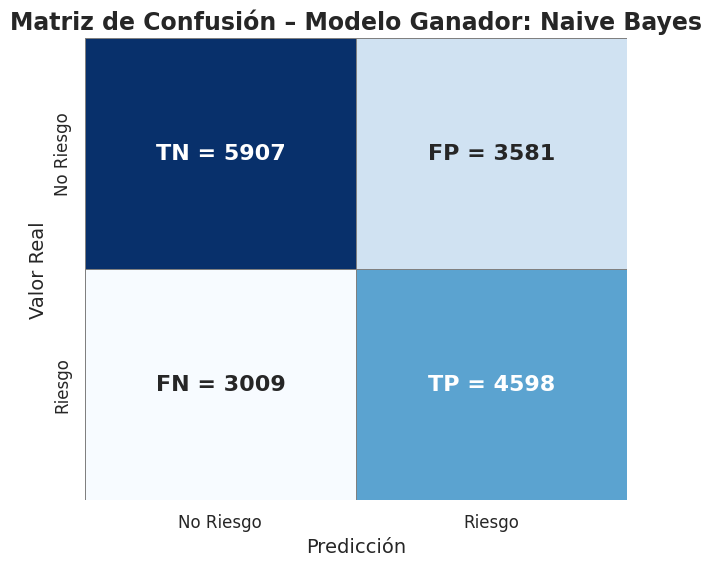

In [111]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Obtener predicciones y matriz de confusión
y_pred_nb = modelos_top["Naive Bayes"].predict(X_test2)
matriz = confusion_matrix(y_test2, y_pred_nb)

TN, FP, FN, TP = matriz.ravel()

# Crear matriz con textos combinados
labels = np.array([
    [f"TN = {TN}", f"FP = {FP}"],
    [f"FN = {FN}", f"TP = {TP}"]
])

plt.figure(figsize=(7,6))
sns.heatmap(
    matriz,
    annot=labels,
    fmt="",
    cmap="Blues",
    linewidths=0.5,
    linecolor="gray",
    cbar=False,
    annot_kws={"size": 16, "weight": "bold"}
)

plt.title("Matriz de Confusión – Modelo Ganador: Naive Bayes", fontsize=17, weight="bold")
plt.xlabel("Predicción", fontsize=14)
plt.ylabel("Valor Real", fontsize=14)

plt.xticks([0.5, 1.5], ["No Riesgo", "Riesgo"], fontsize=12)
plt.yticks([0.5, 1.5], ["No Riesgo", "Riesgo"], fontsize=12)

plt.show()

In [112]:
print("""
============================================================
            CONCLUSIONES FINALES – MODELO NAIVE BAYES
============================================================

1. Desempeño general del modelo
--------------------------------
El modelo Naive Bayes alcanza una accuracy aproximada de 0.615 y un
F1-Score de 0.583. Esto indica que, en un problema real y ruidoso como
éste, logra un equilibrio razonable entre aciertos globales y calidad
de la clasificación.

2. Detección de casos de riesgo (Recall / Sensibilidad)
-------------------------------------------------------
La métrica clave es el Recall (Sensibilidad), que es de aproximadamente
0.604. Es decir, el modelo detecta alrededor del 60% de los estudiantes
que efectivamente están en riesgo crítico.

En términos absolutos:
- TP (verdaderos positivos)  ≈ 4598
- FN (falsos negativos)      = 3009

El número de falsos negativos (3009) es el más bajo entre los modelos
comparados, por lo que Naive Bayes es el que mejor cumple el objetivo
principal del trabajo: minimizar los casos de riesgo no detectados.

3. Utilidad del modelo
----------------------
El modelo es especialmente útil como herramienta de detección temprana.
Aunque no es perfecto, permite identificar un volumen importante de
estudiantes en riesgo crítico a partir de variables demográficas,
educativas y de estilo de vida, sin depender directamente de alcohol,
tabaco o lesiones (que fueron excluidas para evitar fuga de información).

4. Limitaciones
---------------
- La accuracy no es muy alta (~0.615), lo que refleja la complejidad y
  el ruido del problema.
- El modelo genera una cantidad importante de falsos positivos (FP ≈ 3581):
  estudiantes clasificados como riesgo que en realidad no lo son.
- Naive Bayes supone independencia condicional entre variables, algo que
  probablemente no se cumple del todo en la práctica.

5. Posibles mejoras
-------------------
- Explorar modelos más complejos (por ejemplo, Random Forest o Gradient
  Boosting) combinados con técnicas de balanceo de clases.
- Afinar el preprocesamiento y la selección de variables para reducir
  falsos positivos sin aumentar demasiado los falsos negativos.
- Integrar este modelo dentro de un sistema de alerta temprana que combine
  información cuantitativa (encuestas) con evaluación cualitativa
  realizada por equipos escolares.

Conclusión general:
-------------------
Naive Bayes fue elegido como modelo final porque, entre las alternativas
evaluadas, es el que MENOS falsos negativos produce y el que mejor
cumple el objetivo central del proyecto: priorizar la detección de
estudiantes en riesgo crítico, incluso a costa de aceptar un número
mayor de falsos positivos.
============================================================
""")


            CONCLUSIONES FINALES – MODELO NAIVE BAYES

1. Desempeño general del modelo
--------------------------------
El modelo Naive Bayes alcanza una accuracy aproximada de 0.615 y un 
F1-Score de 0.583. Esto indica que, en un problema real y ruidoso como 
éste, logra un equilibrio razonable entre aciertos globales y calidad 
de la clasificación.

2. Detección de casos de riesgo (Recall / Sensibilidad)
-------------------------------------------------------
La métrica clave es el Recall (Sensibilidad), que es de aproximadamente 
0.604. Es decir, el modelo detecta alrededor del 60% de los estudiantes 
que efectivamente están en riesgo crítico.

En términos absolutos:
- TP (verdaderos positivos)  ≈ 4598
- FN (falsos negativos)      = 3009

El número de falsos negativos (3009) es el más bajo entre los modelos 
comparados, por lo que Naive Bayes es el que mejor cumple el objetivo 
principal del trabajo: minimizar los casos de riesgo no detectados.

3. Utilidad del modelo
-------------

/tmp/ipython-input-2919166802.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


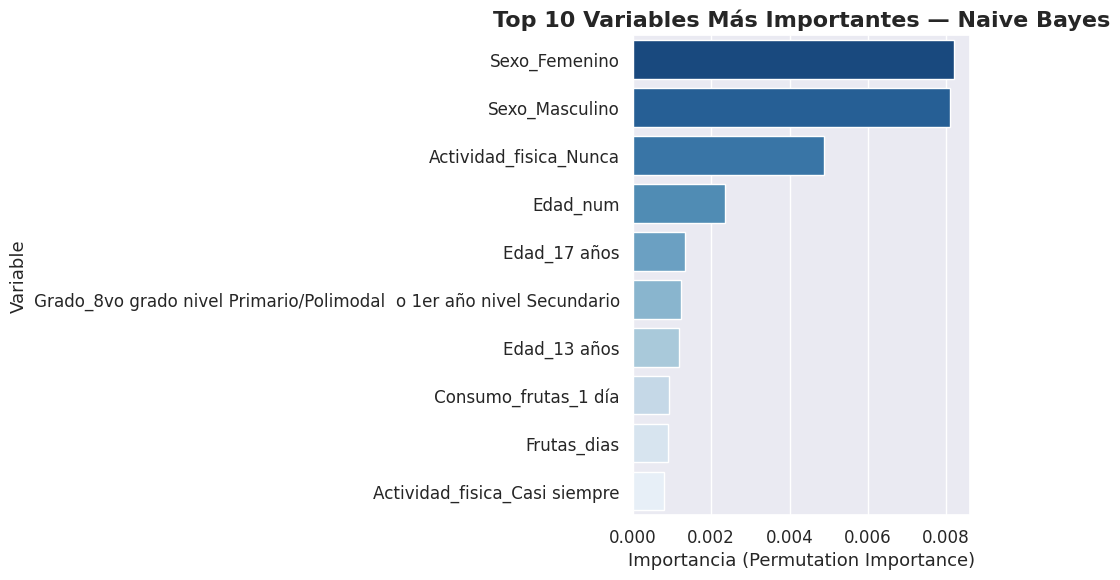

In [113]:
# --- TOP 10 VARIABLES IMPORTANTES PARA NAIVE BAYES ---
import matplotlib.pyplot as plt
import seaborn as sns

# Ordenar de mayor a menor
top10 = importancia_df.sort_values("Importancia", ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top10,
    x="Importancia",
    y="Variable",
    palette="Blues_r"
)

plt.title("Top 10 Variables Más Importantes — Naive Bayes", fontsize=16, weight="bold")
plt.xlabel("Importancia (Permutation Importance)", fontsize=13)
plt.ylabel("Variable", fontsize=13)

plt.tight_layout()
plt.show()

In [114]:
print("""
RESUMEN DEL RANKING DE IMPORTANCIA — MODELO NAIVE BAYES
-------------------------------------------------------

El modelo Naive Bayes identifica que las variables más influyentes
para distinguir entre estudiantes en riesgo y no riesgo son:

1. Variables demográficas:
   - Sexo (Femenino / Masculino)
   - Edad y curso escolar

2. Variables de estilo de vida:
   - Ausencia de actividad física ("Actividad_fisica_Nunca")
   - Frecuencia de consumo de frutas

Estas variables no actúan como causas directas, sino como indicadores
estructurales del contexto socioeducativo y de los hábitos del estudiante.
El modelo utiliza estos patrones para mejorar su capacidad de detección
temprana del riesgo crítico, incluso sin recurrir a variables triviales
como alcohol o tabaco (excluidas para evitar fuga de información).
""")


RESUMEN DEL RANKING DE IMPORTANCIA — MODELO NAIVE BAYES
-------------------------------------------------------

El modelo Naive Bayes identifica que las variables más influyentes 
para distinguir entre estudiantes en riesgo y no riesgo son:

1. Variables demográficas:
   - Sexo (Femenino / Masculino)
   - Edad y curso escolar

2. Variables de estilo de vida:
   - Ausencia de actividad física ("Actividad_fisica_Nunca")
   - Frecuencia de consumo de frutas

Estas variables no actúan como causas directas, sino como indicadores 
estructurales del contexto socioeducativo y de los hábitos del estudiante. 
El modelo utiliza estos patrones para mejorar su capacidad de detección 
temprana del riesgo crítico, incluso sin recurrir a variables triviales 
como alcohol o tabaco (excluidas para evitar fuga de información).

